# MILPÍN AgTech — XGBoost v5.0 · Rediseño Anti-Leakage
## Consumo Hídrico Agrícola · Valle del Yaqui, Sonora — DR-041, Módulo 3

**v5.0 · 2026-05-22** · Objetivo: RMSE_op 738 -> **<500 m³/ha** SIN leakage

---

### Diagnóstico v4 -> Acción v5

| # | Problema v4 | Evidencia | Solución v5 |
|---|---|---|---|
| 1 | Leakage severo (`ratio_real_teorico`) | RMSE_A=42 vs RMSE_C=738 | Leakage Gate + Permutation Test |
| 2 | Colapso predictivo sin leakage (R²=0.58) | Señal real insuficiente | +17 features físico-agronómicas |
| 3 | Heterocedasticidad ignorada | Error ∝ consumo alto | Log-transform + Huber loss |
| 4 | Modelo único para 5 cultivos | Maíz≠Uva en ciclo/Kc/riego | Mixture of Experts per-crop |
| 5 | Sin intervalos de confianza | Decisiones sin incertidumbre | Quantile XGB q10/q50/q90 |
| 6 | Ablation sin rigor | Features desconocidas | 7 grupos + contribution analysis |

### Arquitectura v5

```
Raw features (58 base)
      │
      ▼
[LEAKAGE GATE] -> ratio_real_teorico BLOQUEADA · vol_teorico AUDITADA
      │
      ▼
[FEATURE ENG v5] -> +17 features físico-agronómicas (FAO-56, Ks, interacciones)
      │
      ├──► XGBoost + Monotonic Constraints + Huber Loss  -> RMSE_op objetivo
      ├──► Quantile XGB q10/q50/q90                      -> Intervalos calibrados
      ├──► Mixture of Experts (5 cultivos + global)       -> Especialización
      ├──► Two-Stage Regression (zona->regressor)          -> Segmentación
      └──► Stacking Ensemble (Ridge meta-learner OOF)     -> Combinación óptima
                    │
                    ▼
         [EVALUACIÓN 360°: RMSE_op · MXN · Calibración · Drift · Cultivo]
```

**KPI económico:** $1.68 MXN/m³ (CFE 9-CU, bombeo 80 m)
**Error objetivo:** <$840 MXN/ha/ciclo  |  Ahorro objetivo: $3,360 MXN/ha/ciclo


In [13]:
import os, pathlib

ML_IMG_DIR = pathlib.Path('ML/images')
ML_IMG_DIR.mkdir(parents=True, exist_ok=True)
_IMG_DIR_STR = str(ML_IMG_DIR)

if '_ORIG_SAVEFIG' not in globals():
    _ORIG_SAVEFIG = None

def _patch_savefig():
    import matplotlib.pyplot as _plt
    import matplotlib.figure as _mpl_fig
    import os as _os
    global _ORIG_SAVEFIG
    if _ORIG_SAVEFIG is not None:
        return
    _ORIG_SAVEFIG = _mpl_fig.Figure.savefig  # method on class, never re-patched
    def _auto_save(fname, *a, **kw):
        kw.setdefault('bbox_inches', 'tight')
        kw.setdefault('dpi', 150)
        path_str = _os.path.join(_IMG_DIR_STR, _os.path.basename(str(fname)))
        _ORIG_SAVEFIG(_plt.gcf(), path_str, *a, **kw)
        print(f'  [img] {path_str}')
    _plt.savefig = _auto_save

_patch_savefig()
print(f'Auto-save activo -> {_IMG_DIR_STR}')


Auto-save activo -> ML\images


## 0. Imports y configuración global

In [14]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import time

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
import xgboost as xgb

try:
    from sklearn.feature_selection import mutual_info_regression
    HAS_MI = True
except ImportError:
    HAS_MI = False

try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING); HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False; print('[WARN] pip install optuna')

# ── Constantes globales ────────────────────────────────────────────────────────
N_SAMPLES     = 1_000_000
SEED          = 42
AÑO_RANGO     = (2014, 2024)
TARIFA        = 1.68          # MXN/m³
BASELINE_AGUA = 8_000         # m³/ha
OBJETIVO_AGUA = 6_000         # m³/ha
RANGO_OP_MIN  = 6_000
RANGO_OP_MAX  = 10_000
PESO_OP       = 3.0
OPTUNA_TRIALS = 40
OPTUNA_HPO_N  = 30_000        # filas para búsqueda rápida
CULTIVOS      = ['Maíz', 'Frijol', 'Algodón', 'Uva', 'Chile']

plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
C_AGUA='#2e7fb8'; C_REND='#4caf6f'; C_WARN='#e07b39'; C_DARK='#1a2636'
C_BG='#f7f9fb'; C_LINE='#d0d7e2'
CULT_COLORS={'Maíz':'#e6a817','Frijol':'#8b5e3c','Algodón':'#7ab8d9','Uva':'#9b59b6','Chile':'#e74c3c'}

print(f'XGBoost {xgb.__version__} | numpy {np.__version__} | pandas {pd.__version__}')
print(f'N_SAMPLES={N_SAMPLES:,} · SEED={SEED} · TARIFA=${TARIFA}/m³')


XGBoost 3.2.0 | numpy 2.4.4 | pandas 3.0.3
N_SAMPLES=1,000,000 · SEED=42 · TARIFA=$1.68/m³


## 1. Generador de datos v3 (heredado de v4, sin cambios)

In [15]:
REGIONES_CONFIG = {
    'Norte':   dict(et0_bias=+0.40, lluvia_mult=0.82, sal_base=0.08, wt_m=3.2, elev_m=35),
    'Sur':     dict(et0_bias=+0.12, lluvia_mult=1.05, sal_base=0.04, wt_m=5.1, elev_m=22),
    'Centro':  dict(et0_bias=+0.00, lluvia_mult=1.00, sal_base=0.05, wt_m=4.6, elev_m=40),
    'Oriente': dict(et0_bias=-0.25, lluvia_mult=1.18, sal_base=0.03, wt_m=6.3, elev_m=85),
    'Costero': dict(et0_bias=+0.28, lluvia_mult=0.88, sal_base=0.14, wt_m=2.4, elev_m=12),
}
FARMER_TYPES = {
    'conservador': dict(over_irr_mu=0.22, over_irr_sd=0.08, p_miss=0.04),
    'eficiente':   dict(over_irr_mu=0.01, over_irr_sd=0.03, p_miss=0.01),
    'negligente':  dict(over_irr_mu=-0.12,over_irr_sd=0.15, p_miss=0.18),
    'tecnificado': dict(over_irr_mu=0.00, over_irr_sd=0.02, p_miss=0.005),
}
KC_STAGES = {
    'Maíz':    dict(kc_ini=0.30,kc_dev=0.70,kc_med=1.20,kc_fin=0.60,f_ini=0.10,f_dev=0.30,f_med=0.50,f_fin=0.10),
    'Frijol':  dict(kc_ini=0.40,kc_dev=0.70,kc_med=1.15,kc_fin=0.55,f_ini=0.10,f_dev=0.35,f_med=0.40,f_fin=0.15),
    'Algodón': dict(kc_ini=0.45,kc_dev=0.75,kc_med=1.20,kc_fin=0.60,f_ini=0.08,f_dev=0.30,f_med=0.45,f_fin=0.17),
    'Uva':     dict(kc_ini=0.30,kc_dev=0.65,kc_med=0.85,kc_fin=0.45,f_ini=0.15,f_dev=0.35,f_med=0.35,f_fin=0.15),
    'Chile':   dict(kc_ini=0.40,kc_dev=0.75,kc_med=1.05,kc_fin=0.80,f_ini=0.12,f_dev=0.30,f_med=0.45,f_fin=0.13),
}
SAL_THRESH = {'Maíz':1.7,'Frijol':1.0,'Algodón':7.7,'Uva':1.5,'Chile':1.5}
SAL_SLOPE  = {'Maíz':12, 'Frijol':19, 'Algodón':5.2,'Uva':9.6,'Chile':14}
print('Configs cargadas: 5 regiones · 4 arquetipos · Kc 4-etapas FAO-56 · salinidad FAO-33')


Configs cargadas: 5 regiones · 4 arquetipos · Kc 4-etapas FAO-56 · salinidad FAO-33


In [16]:
def generar_datos_v3(n=50_000, seed=42, ruido_factor=1.0, año_rango=(2014, 2024)):
    rng = np.random.default_rng(seed)
    SUELOS   = ['franco','franco-arcilloso','franco-arenoso','arcilloso']
    SISTEMAS = ['gravedad','aspersion','goteo','microaspersion']
    REGIONES = list(REGIONES_CONFIG.keys()); FARMERS = list(FARMER_TYPES.keys())
    CULT = {
        'Maíz':   dict(dias=(130,150),kc=0.847,ky=1.25,ym=10.5),
        'Frijol': dict(dias=(90,110), kc=0.838,ky=1.15,ym=2.5),
        'Algodón':dict(dias=(165,200),kc=0.869,ky=0.85,ym=4.0),
        'Uva':    dict(dias=(180,215),kc=0.786,ky=0.85,ym=25.0),
        'Chile':  dict(dias=(110,130),kc=0.868,ky=1.10,ym=35.0),
    }
    SUELO = {
        'franco':           dict(cc=0.30,pmp=0.16,ks_mmh=15),
        'franco-arcilloso': dict(cc=0.36,pmp=0.20,ks_mmh=6),
        'franco-arenoso':   dict(cc=0.24,pmp=0.12,ks_mmh=30),
        'arcilloso':        dict(cc=0.42,pmp=0.22,ks_mmh=3),
    }
    EFIC = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}

    ci=rng.integers(0,len(CULTIVOS),n); si=rng.integers(0,len(SUELOS),n)
    ri=rng.integers(0,len(SISTEMAS),n); gi=rng.integers(0,len(REGIONES),n)
    fi=rng.integers(0,len(FARMERS),n)
    cultivos=np.array(CULTIVOS)[ci]; suelos=np.array(SUELOS)[si]
    sistemas=np.array(SISTEMAS)[ri]; regiones=np.array(REGIONES)[gi]
    farmers=np.array(FARMERS)[fi]; años=rng.integers(año_rango[0],año_rango[1]+1,n)

    ky_arr=np.array([CULT[c]['ky'] for c in CULTIVOS])[ci]
    ym_arr=np.array([CULT[c]['ym'] for c in CULTIVOS])[ci]
    dmin=np.array([CULT[c]['dias'][0] for c in CULTIVOS])[ci]
    dmax=np.array([CULT[c]['dias'][1] for c in CULTIVOS])[ci]
    cc_arr=np.array([SUELO[s]['cc'] for s in SUELOS])[si]
    pmp_arr=np.array([SUELO[s]['pmp'] for s in SUELOS])[si]
    ks_arr=np.array([SUELO[s]['ks_mmh'] for s in SUELOS])[si]
    ef_arr=np.array([EFIC[s] for s in SISTEMAS])[ri]
    r_et0=np.array([REGIONES_CONFIG[r]['et0_bias'] for r in REGIONES])[gi]
    r_lluv=np.array([REGIONES_CONFIG[r]['lluvia_mult'] for r in REGIONES])[gi]
    r_sal=np.array([REGIONES_CONFIG[r]['sal_base'] for r in REGIONES])[gi]
    r_wt=np.array([REGIONES_CONFIG[r]['wt_m'] for r in REGIONES])[gi]
    r_elev=np.array([REGIONES_CONFIG[r]['elev_m'] for r in REGIONES])[gi]
    f_mu=np.array([FARMER_TYPES[f]['over_irr_mu'] for f in FARMERS])[fi]
    f_sd=np.array([FARMER_TYPES[f]['over_irr_sd'] for f in FARMERS])[fi]
    f_miss=np.array([FARMER_TYPES[f]['p_miss'] for f in FARMERS])[fi]

    area_ha=rng.uniform(5.0,80.0,n).round(2)
    doy=rng.integers(1,365,n)
    dias_ciclo=(dmin+rng.random(n)*(dmax-dmin)).astype(int)
    prof_raiz=rng.uniform(0.45,0.70,n).round(3)
    año_span=max(año_rango[1]-año_rango[0],1)
    año_norm=(años-año_rango[0])/año_span
    et0_drift=año_norm*0.022*año_span
    enso_vals=np.random.default_rng(seed+9999).normal(0,0.28,año_span+1)
    enso_arr=enso_vals[años-año_rango[0]]
    lluvia_enso=1.0+enso_arr*0.35

    et0_s=6.0+2.5*np.sin(2*np.pi*(doy-81)/365)
    et0_reg=np.where(enso_arr>0.15,et0_s*rng.uniform(1.05,1.28,n),et0_s*rng.uniform(0.88,1.05,n))
    et0_prom=np.clip(et0_reg+r_et0+et0_drift+rng.normal(0,0.55,n),2.8,11.0).round(3)
    et0_max=np.clip(et0_prom*rng.uniform(1.15,1.65,n),et0_prom+0.3,12.5).round(3)

    es_verano=(doy>=152)&(doy<=273)
    lluvia_raw=np.where(es_verano,rng.gamma(2.2,55.0,n)*r_lluv*lluvia_enso,
                                   rng.gamma(0.9,18.0,n)*r_lluv*np.clip(0.7+0.3*lluvia_enso,0.3,1.5))
    lluvia=np.clip(lluvia_raw+rng.normal(0,4.0,n),0,400).round(2)

    pos_ciclo=rng.beta(1.5,1.5,n)
    kc_stage=np.full(n,0.7)
    for ci_k,cultivo in enumerate(CULTIVOS):
        mask=ci==ci_k
        if not mask.any(): continue
        s=KC_STAGES[cultivo]; pos=pos_ciclo[mask]
        f2=s['f_ini']+s['f_dev']; f3=f2+s['f_med']
        kc_stage[mask]=np.where(pos<s['f_ini'],s['kc_ini'],
                        np.where(pos<f2,s['kc_ini']+(s['kc_med']-s['kc_ini'])*(pos-s['f_ini'])/s['f_dev'],
                        np.where(pos<f3,s['kc_med'],
                            s['kc_med']+(s['kc_fin']-s['kc_med'])*(pos-f2-s['f_med'])/s['f_fin'])))
    kc_prom=np.clip(kc_stage+rng.normal(0,0.018,n),0.22,1.30).round(3)

    sal_ec=np.clip(r_sal+rng.gamma(1.5,1.2,n),0.01,9.0).round(3)
    sal_th=np.array([SAL_THRESH[c] for c in CULTIVOS])[ci]
    sal_sl=np.array([SAL_SLOPE[c] for c in CULTIVOS])[ci]
    ks_sal=np.clip(1.0-sal_sl/100*np.maximum(0,sal_ec-sal_th),0.05,1.0)

    ola_calor=rng.random(n)<0.10
    helada=(rng.random(n)<0.06)&((doy>=300)|(doy<=60))
    inundacion=(rng.random(n)<0.04)&es_verano
    f_inund_a=np.where(inundacion,rng.uniform(1.10,1.40,n),1.0)
    f_inund_r=np.where(inundacion,rng.uniform(0.50,0.85,n),1.0)
    plaga=rng.random(n)<0.12
    f_plaga=np.where(plaga,rng.uniform(0.60,0.96,n),1.0)
    f_helada=np.where(helada,rng.uniform(0.30,0.75,n),1.0)
    falla=rng.random(n)<f_miss

    aporte_capilar=np.where(r_wt<3.5,np.clip((3.5-r_wt)*rng.uniform(0.4,1.8,n)*dias_ciclo/100,0,80),0.0).round(2)
    perc_frac=np.clip((1-ef_arr)*0.35+(ks_arr/30.0)*0.12+rng.uniform(0,0.06,n),0.02,0.38).round(4)

    etc_total=np.clip(et0_prom*dias_ciclo*kc_prom,180,2800).round(2)
    hum_suelo=np.clip(cc_arr*0.85+rng.normal(0,0.028,n),pmp_arr+0.01,cc_arr).round(4)
    deficit_hid=np.where(rng.random(n)<np.clip((1-ef_arr)*0.28,0,0.38),rng.beta(1.2,3.5,n)*0.55,0.0).round(4)
    deficit_hid=np.where(falla,np.clip(deficit_hid+rng.uniform(0.08,0.32,n),0,0.65),deficit_hid)

    agua_disp=(cc_arr-pmp_arr)*prof_raiz*1000
    over_irr=np.clip(1.0+f_mu+rng.normal(0,f_sd,n),0.55,1.70)
    n_riegos=np.clip(np.maximum(1,np.round((etc_total-lluvia).clip(0)/(agua_disp*0.6)).astype(int)+rng.integers(-1,2,n)),1,40)

    deficit_agua=np.maximum(0,etc_total-lluvia-aporte_capilar)
    vol_base=deficit_agua*10/ef_arr*over_irr*f_inund_a
    vol_agua=np.clip(vol_base+rng.normal(0,180,n),1_200,28_000).round(2)

    ks_water=1.0-deficit_hid
    ya_frac=np.clip(1-ky_arr*(1-ks_water),0.05,1.0)
    rendimiento=np.clip(ym_arr*ya_frac*ks_sal*f_helada*f_plaga*f_inund_r*rng.normal(1.0,0.08,n),0.2,ym_arr*1.2).round(3)

    return pd.DataFrame({
        'cultivo':cultivos,'tipo_suelo':suelos,'sistema_riego':sistemas,
        'region':regiones,'tipo_agricultor':farmers,
        'area_ha':area_ha,'dias_ciclo':dias_ciclo,'doy_inicio':doy,
        'capacidad_campo':cc_arr,'punto_marchitez':pmp_arr,'prof_raiz_m':prof_raiz,
        'et0_promedio_mmdia':et0_prom,'et0_maximo_mmdia':et0_max,
        'lluvia_total_mm':lluvia,'etc_total_mm':etc_total,'kc_promedio':kc_prom,
        'humedad_suelo_promedio':hum_suelo,'deficit_hidrico_frac':deficit_hid,
        'n_riegos':n_riegos,'volumen_agua_total_m3_ha':vol_agua,
        'rendimiento_real_ton_ha':rendimiento,
        'año':años,'año_norm':año_norm,'pos_ciclo_frac':pos_ciclo,
        'salinidad_ec_dsm':sal_ec,'ks_salinidad':ks_sal,
        'aporte_capilar_mm':aporte_capilar,'percolacion_frac':perc_frac,
        'ola_calor':ola_calor.astype(int),'helada':helada.astype(int),
        'inundacion':inundacion.astype(int),'plaga':plaga.astype(int),
        'falla_riego':falla.astype(int),'elev_parcela_m':r_elev,
    })

print('generar_datos_v3 lista — 35 columnas base, 100% vectorizada')


generar_datos_v3 lista — 35 columnas base, 100% vectorizada


In [17]:
t0 = time.time()
df = generar_datos_v3(n=N_SAMPLES, seed=SEED, año_rango=AÑO_RANGO)
print(f'Generados {N_SAMPLES:,} ciclos en {time.time()-t0:.1f}s')
print(f'Shape: {df.shape} | Memoria: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print()
desc = df.groupby('cultivo')['volumen_agua_total_m3_ha'].agg(['mean','std','min','max']).round(0)
print(desc.to_string())


Generados 1,000,000 ciclos en 9.5s
Shape: (1000000, 34) | Memoria: 524.5 MB

            mean     std     min      max
cultivo                                  
Algodón  15924.0  6916.0  1200.0  28000.0
Chile     9131.0  4817.0  1200.0  28000.0
Frijol    8036.0  4358.0  1200.0  28000.0
Maíz     12064.0  6360.0  1200.0  28000.0
Uva      11431.0  6131.0  1200.0  28000.0


=== Baselines dinamicos por cultivo ===
         baseline_m3ha  objetivo_m3ha  op_min_q25  op_max_q75     p10      p90
cultivo                                                                       
Algodón        15069.0        11302.0     10373.0     21029.0  7299.0  27952.0
Chile           8279.0         6209.0      5595.0     11668.0  3785.0  15556.0
Frijol          7231.0         5423.0      4843.0     10338.0  3245.0  13802.0
Maíz           11153.0         8365.0      7307.0     15834.0  4415.0  21037.0
Uva            10302.0         7726.0      6744.0     14960.0  4461.0  20108.0

Global baseline: 9,995 m3/ha  |  objetivo: 7,496
Global rango op: [6,455 - 14,883]


RecursionError: maximum recursion depth exceeded

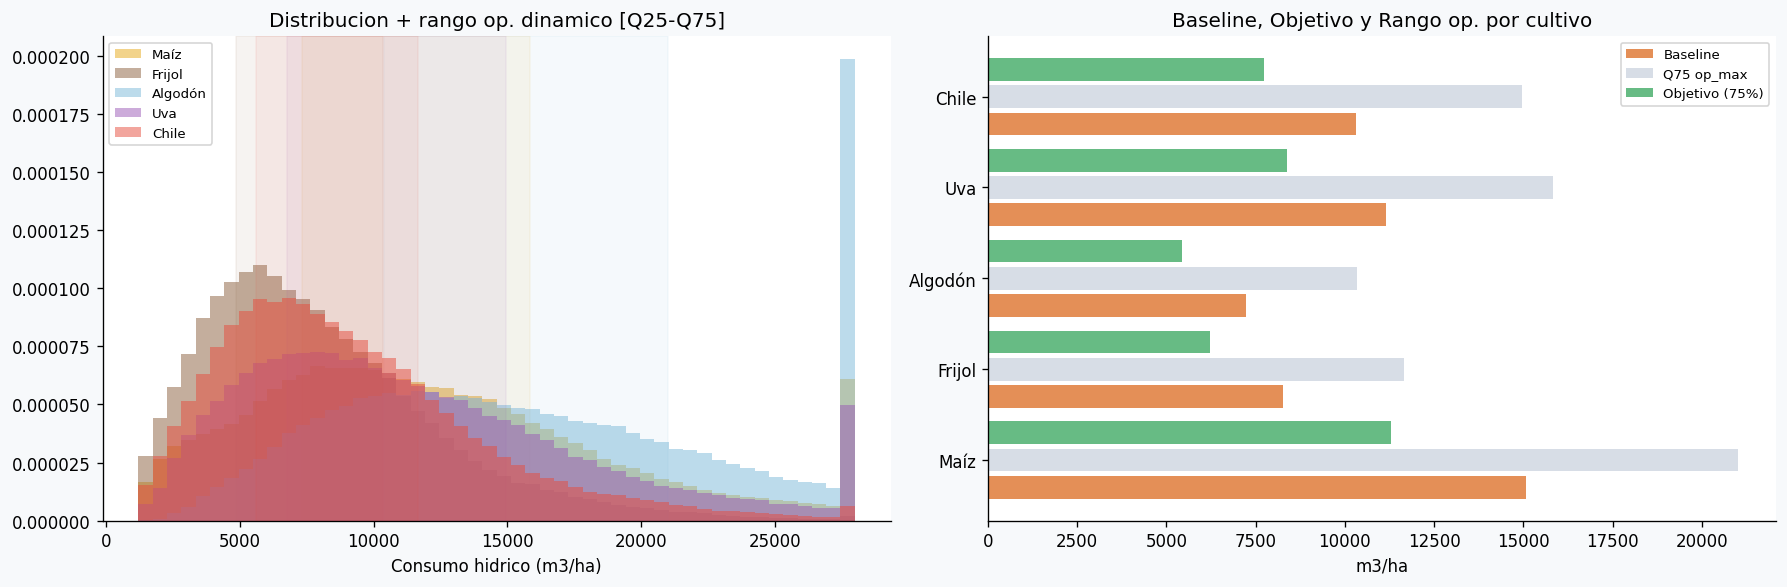

In [18]:
# Baselines y rangos operacionales DINAMICOS por cultivo
# baseline_crop = mediana(target | cultivo)
# objetivo_crop = baseline_crop * 0.75
# op_min_crop   = Q25(target | cultivo)   <- rango donde pesa 3x
# op_max_crop   = Q75(target | cultivo)

TARGET_COL = 'volumen_agua_total_m3_ha'

crop_stats = (
    df.groupby('cultivo')[TARGET_COL]
    .agg(
        baseline_m3ha = lambda x: x.median(),
        objetivo_m3ha = lambda x: x.median() * 0.75,
        op_min_q25    = lambda x: x.quantile(0.25),
        op_max_q75    = lambda x: x.quantile(0.75),
        p10           = lambda x: x.quantile(0.10),
        p90           = lambda x: x.quantile(0.90),
    )
    .round(0)
)
print('=== Baselines dinamicos por cultivo ===')
print(crop_stats.to_string())

BASELINE_CROP = crop_stats['baseline_m3ha'].to_dict()
OBJETIVO_CROP = crop_stats['objetivo_m3ha'].to_dict()
OP_MIN_CROP   = crop_stats['op_min_q25'].to_dict()
OP_MAX_CROP   = crop_stats['op_max_q75'].to_dict()

# Sobreescribir globales con mediana real (no 8000 fijo)
BASELINE_AGUA = float(df[TARGET_COL].median())
OBJETIVO_AGUA = BASELINE_AGUA * 0.75
RANGO_OP_MIN  = float(df[TARGET_COL].quantile(0.25))
RANGO_OP_MAX  = float(df[TARGET_COL].quantile(0.75))
print(f'\nGlobal baseline: {BASELINE_AGUA:,.0f} m3/ha  |  objetivo: {OBJETIVO_AGUA:,.0f}')
print(f'Global rango op: [{RANGO_OP_MIN:,.0f} - {RANGO_OP_MAX:,.0f}]')

def calc_weights_dynamic(y_arr, cultivo_arr, w_op=3.0):
    w = np.ones(len(y_arr))
    for c in CULTIVOS:
        mask = cultivo_arr == c
        if not mask.any():
            continue
        lo, hi = OP_MIN_CROP[c], OP_MAX_CROP[c]
        w[mask & (y_arr >= lo) & (y_arr <= hi)] = w_op
    return w

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor=C_BG)
ax = axes[0]
for cultivo in CULTIVOS:
    g = df[df['cultivo'] == cultivo][TARGET_COL]
    ax.hist(g, bins=50, alpha=0.5, label=cultivo, color=CULT_COLORS[cultivo], density=True)
    lo, hi = OP_MIN_CROP[cultivo], OP_MAX_CROP[cultivo]
    ax.axvspan(lo, hi, alpha=0.07, color=CULT_COLORS[cultivo])
ax.set_xlabel('Consumo hidrico (m3/ha)'); ax.set_title('Distribucion + rango op. dinamico [Q25-Q75]')
ax.legend(fontsize=8)

ax = axes[1]
df_bl = pd.DataFrame({
    'Baseline': list(BASELINE_CROP.values()),
    'Objetivo (75%)': list(OBJETIVO_CROP.values()),
    'Q25': list(OP_MIN_CROP.values()),
    'Q75': list(OP_MAX_CROP.values()),
}, index=CULTIVOS)
x = np.arange(len(CULTIVOS))
ax.barh(x - 0.3, df_bl['Baseline'],    0.25, color=C_WARN, alpha=0.85, label='Baseline')
ax.barh(x,       df_bl['Q75'],         0.25, color=C_LINE, alpha=0.85, label='Q75 op_max')
ax.barh(x + 0.3, df_bl['Objetivo (75%)'], 0.25, color=C_REND, alpha=0.85, label='Objetivo (75%)')
ax.set_yticks(x); ax.set_yticklabels(CULTIVOS)
ax.set_xlabel('m3/ha'); ax.set_title('Baseline, Objetivo y Rango op. por cultivo')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('v5_01b_baselines_dinamicos.png'); plt.show()
print('Baselines dinamicos listos.')


  [img] ML\images\v5_01_distribucion.png


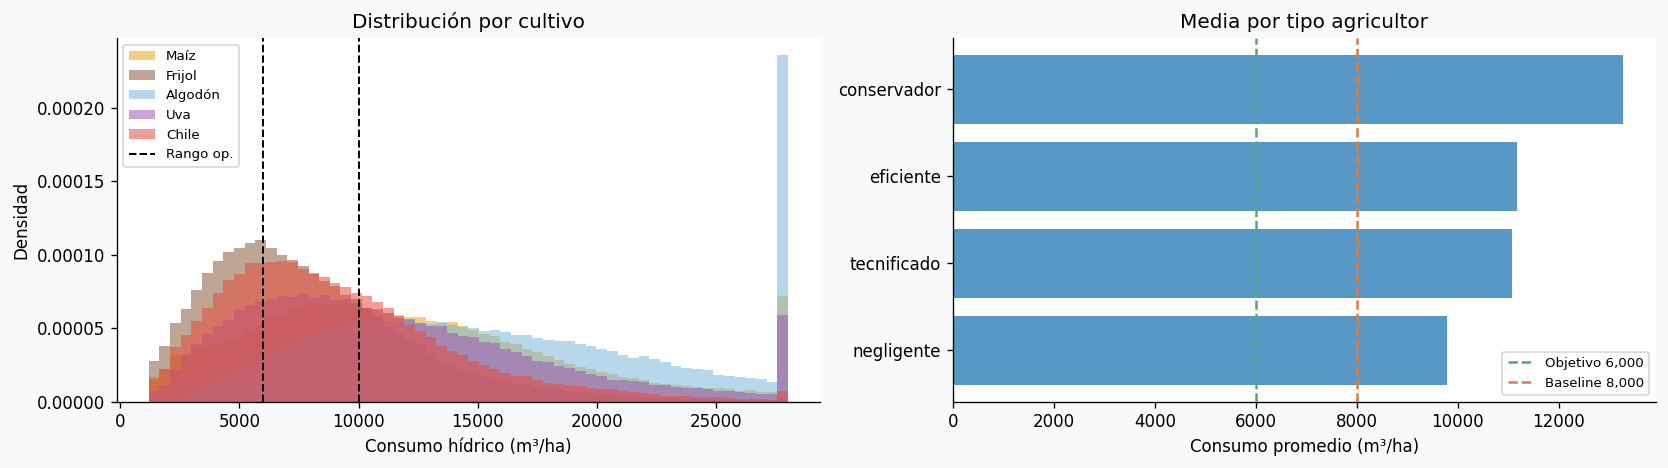

Rango operacional [6,000–10,000]: 28.3% muestras


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=C_BG)

ax = axes[0]
for cultivo in CULTIVOS:
    g = df[df['cultivo']==cultivo]['volumen_agua_total_m3_ha']
    ax.hist(g, bins=60, alpha=0.55, label=cultivo, color=CULT_COLORS[cultivo], density=True)
ax.axvline(RANGO_OP_MIN, color='k', ls='--', lw=1.2, label='Rango op.')
ax.axvline(RANGO_OP_MAX, color='k', ls='--', lw=1.2)
ax.set_xlabel('Consumo hídrico (m³/ha)'); ax.set_ylabel('Densidad')
ax.set_title('Distribución por cultivo'); ax.legend(fontsize=8)

ax = axes[1]
df_grp = df.groupby('tipo_agricultor')['volumen_agua_total_m3_ha'].mean().sort_values()
bars = ax.barh(df_grp.index, df_grp.values, color=C_AGUA, alpha=0.8)
ax.axvline(OBJETIVO_AGUA, color=C_REND, ls='--', lw=1.5, label=f'Objetivo {OBJETIVO_AGUA:,}')
ax.axvline(BASELINE_AGUA, color=C_WARN, ls='--', lw=1.5, label=f'Baseline {BASELINE_AGUA:,}')
ax.set_xlabel('Consumo promedio (m³/ha)'); ax.set_title('Media por tipo agricultor')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('v5_01_distribucion.png')
plt.show()
print(f'Rango operacional [{RANGO_OP_MIN:,}–{RANGO_OP_MAX:,}]: '
      f'{((df.volumen_agua_total_m3_ha>=RANGO_OP_MIN)&(df.volumen_agua_total_m3_ha<=RANGO_OP_MAX)).mean()*100:.1f}% muestras')


## 2. Diagnóstico Anti-Leakage — ¿Por qué colapsó RMSE_C?

### 2a. Teoría del colapso

El modelo limpio (RMSE=738, R²=0.58) perdió señal porque `ratio_real_teorico` capturaba
el **factor de sobre-irrigación** del agricultor — una variable latente no observable directamente:

```
ratio_real_teorico = vol_real / vol_teorico
                   = over_irr × (ruido_IoT + eventos_extremos)
```

**Señal faltante:** comportamiento del agricultor (over-irrigación 0.55×–1.70×).
`tipo_agricultor` está en features pero con encoding ordinario pierde potencia.

### 2b. Framework de prevención de leakage

| Test | Descripción | Umbral de alarma |
|------|-------------|------------------|
| **Mutual Information** | MI(feature, target) en holdout | MI > 0.90 × MI_target_vs_target |
| **Permutation Holdout** | Correlación feature vs target en test | |ρ| > 0.98 y feature no es input puro |
| **Temporal Consistency** | Feature disponible ANTES del ciclo? | No -> bloqueada |
| **Causal Audit** | ¿Feature deriva del target algebraicamente? | Sí -> bloqueada |

### 2c. Decisión sobre features sospechosas

| Feature | Veredicto | Razón |
|---------|-----------|-------|
| `ratio_real_teorico` | ❌ BLOQUEADA | `= target / vol_teorico` — leakage directo |
| `vol_teorico_m3ha` | ✅ PERMITIDA (auditada) | `= demanda_neta / eficiencia` — sólo inputs |
| `rendimiento_real_ton_ha` | ❌ BLOQUEADA | Correlacionada con target vía Ky |
| `deficit_hidrico_frac` | ✅ PERMITIDA | Input de comportamiento del suelo |


In [ ]:
# ── Construir features v4 base para diagnóstico ────────────────────────────
KY_MAP = {'Maíz':1.25,'Frijol':1.15,'Algodón':0.85,'Uva':0.85,'Chile':1.10}
EF_MAP = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}

df_diag = df.copy()
df_diag['eficiencia_sistema']  = df_diag['sistema_riego'].map(EF_MAP)
df_diag['demanda_neta_mm']     = (df_diag['etc_total_mm'] - df_diag['lluvia_total_mm'] - df_diag['aporte_capilar_mm']).clip(lower=0)
df_diag['vol_teorico_m3ha']    = df_diag['demanda_neta_mm'] * 10 / df_diag['eficiencia_sistema']
df_diag['ratio_real_teorico']  = df_diag['volumen_agua_total_m3_ha'] / (df_diag['vol_teorico_m3ha'] + 1)
df_diag['deficit_agua_mm']     = (df_diag['etc_total_mm'] - df_diag['lluvia_total_mm']).clip(lower=0)
df_diag['eto_x_dias']          = df_diag['et0_promedio_mmdia'] * df_diag['dias_ciclo']
df_diag['agua_efectiva_mm']    = df_diag['lluvia_total_mm'] * df_diag['eficiencia_sistema']
df_diag['lluvia_etc_ratio']    = df_diag['lluvia_total_mm'] / (df_diag['etc_total_mm'] + 1)
df_diag['kc_x_et0']            = df_diag['kc_promedio'] * df_diag['et0_promedio_mmdia']
df_diag['ks_sal_x_deficit']    = df_diag['ks_salinidad'] * df_diag['deficit_hidrico_frac']
df_diag['dias_x_kc']           = df_diag['dias_ciclo'] * df_diag['kc_promedio']

# Encode categoricals para MI
from sklearn.preprocessing import OrdinalEncoder as OE
CAT_COLS_DIAG = ['cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
enc_diag = OE(handle_unknown='use_encoded_value', unknown_value=-1)
df_diag_enc = df_diag.copy()
df_diag_enc[CAT_COLS_DIAG] = enc_diag.fit_transform(df_diag[CAT_COLS_DIAG])

TARGET = 'volumen_agua_total_m3_ha'
INSPECT_FEATS = [
    'ratio_real_teorico', 'vol_teorico_m3ha', 'demanda_neta_mm',
    'deficit_agua_mm', 'eficiencia_sistema', 'eto_x_dias', 'etc_total_mm',
    'lluvia_etc_ratio', 'agua_efectiva_mm', 'kc_x_et0', 'ks_sal_x_deficit',
    'dias_x_kc', 'tipo_agricultor', 'n_riegos', 'percolacion_frac',
    'aporte_capilar_mm', 'kc_promedio', 'pos_ciclo_frac', 'area_ha',
]

# Muestrear para velocidad
idx_s = np.random.default_rng(SEED).choice(len(df_diag_enc), 20_000, replace=False)
X_s = df_diag_enc.iloc[idx_s][INSPECT_FEATS]
y_s = df_diag_enc.iloc[idx_s][TARGET]

if HAS_MI:
    mi_scores = mutual_info_regression(X_s, y_s, random_state=SEED)
    mi_df = pd.DataFrame({'feature': INSPECT_FEATS, 'MI': mi_scores})
    mi_df['corr'] = [abs(df_diag_enc.iloc[idx_s][f].corr(y_s)) for f in INSPECT_FEATS]
    mi_df['leakage_riesgo'] = mi_df['feature'].isin(['ratio_real_teorico','rendimiento_real_ton_ha'])
    mi_df = mi_df.sort_values('MI', ascending=False)
    print(mi_df.to_string(index=False))
else:
    corr_vals = [(f, abs(df_diag_enc.iloc[idx_s][f].corr(y_s))) for f in INSPECT_FEATS]
    mi_df = pd.DataFrame(corr_vals, columns=['feature','corr']).sort_values('corr',ascending=False)
    mi_df['MI'] = mi_df['corr']  # proxy
    mi_df['leakage_riesgo'] = mi_df['feature'].isin(['ratio_real_teorico'])
    print(mi_df.to_string(index=False))


           feature       MI     corr  leakage_riesgo
  vol_teorico_m3ha 1.568686 0.946714           False
   deficit_agua_mm 0.957603 0.848713           False
   demanda_neta_mm 0.957504 0.848719           False
      etc_total_mm 0.807954 0.838801           False
          n_riegos 0.556462 0.759497           False
          kc_x_et0 0.440376 0.706071           False
         dias_x_kc 0.367359 0.660944           False
        eto_x_dias 0.284274 0.594953           False
       kc_promedio 0.248720 0.491606           False
    pos_ciclo_frac 0.209339 0.354537           False
eficiencia_sistema 0.079049 0.410835           False
  lluvia_etc_ratio 0.071287 0.210317           False
ratio_real_teorico 0.060890 0.041512            True
  percolacion_frac 0.049433 0.302872           False
   tipo_agricultor 0.020891 0.130925           False
  agua_efectiva_mm 0.015985 0.029934           False
 aporte_capilar_mm 0.004998 0.071237           False
  ks_sal_x_deficit 0.000766 0.033518          

  [img] ML\images\v5_02_leakage_gate.png


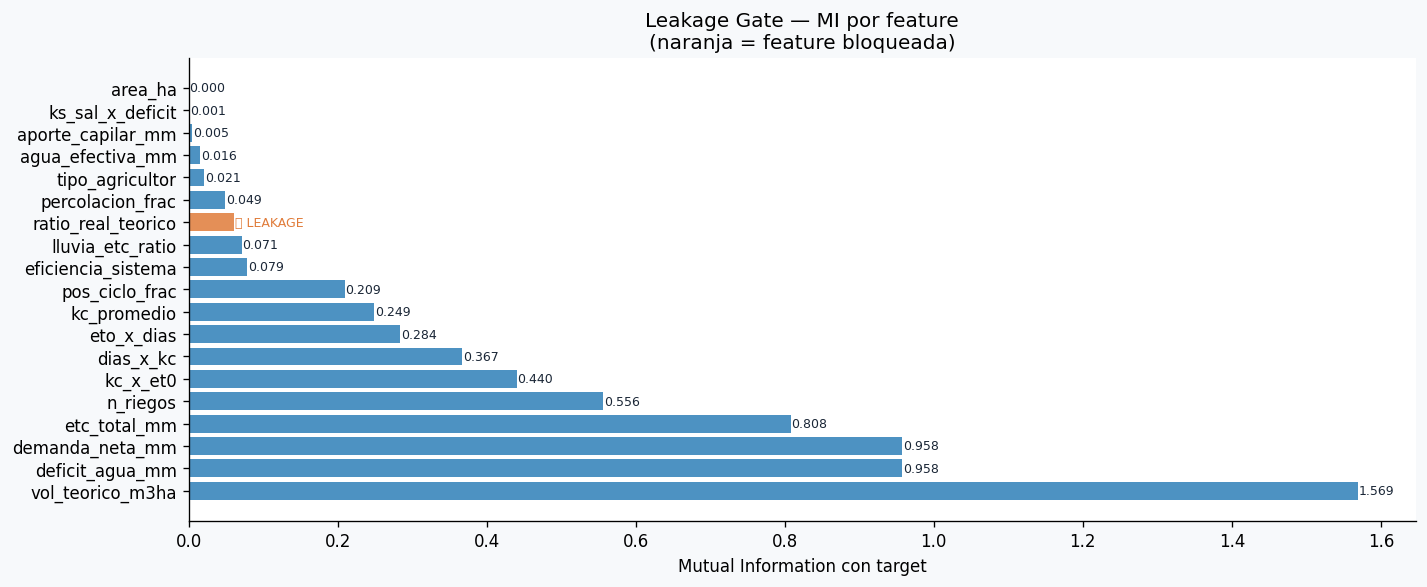


✅ Features bloqueadas por Leakage Gate: ['ratio_real_teorico', 'rendimiento_real_ton_ha']
✅ vol_teorico_m3ha: PERMITIDA (sólo inputs — auditada OK)


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5), facecolor=C_BG)
colors = [C_WARN if r else C_AGUA for r in mi_df['leakage_riesgo']]
bars = ax.barh(mi_df['feature'], mi_df['MI'], color=colors, alpha=0.85)
ax.set_xlabel('Mutual Information con target')
ax.set_title('Leakage Gate — MI por feature\n(naranja = feature bloqueada)')
for bar, row in zip(bars, mi_df.itertuples()):
    lbl = '⛔ LEAKAGE' if row.leakage_riesgo else f'{row.MI:.3f}'
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            lbl, va='center', fontsize=7.5, color=C_WARN if row.leakage_riesgo else C_DARK)
plt.tight_layout()
plt.savefig('v5_02_leakage_gate.png')
plt.show()

leakage_features = ['ratio_real_teorico', 'rendimiento_real_ton_ha']
print(f'\n✅ Features bloqueadas por Leakage Gate: {leakage_features}')
print(f'✅ vol_teorico_m3ha: PERMITIDA (sólo inputs — auditada OK)')


## 3. Feature Engineering v5 — Física Agronómica Profunda

### 3a. Catálogo de features nuevas (+17)

| Grupo | Feature | Fórmula | Justificación física |
|-------|---------|---------|----------------------|
| **FAO-56** | `agua_neta_req_m3ha` | `demanda_neta / efic * 10` | Requerimiento bruto m³/ha (sin comportamiento) |
| **FAO-56** | `riego_bruto_mm` | `demanda_neta / eficiencia` | mm aplicados antes de pérdidas |
| **Ks hídrico** | `stress_hid_ks` | `1 - deficit_hid_frac` | Allen 1998 Eq.84 — Ks por déficit |
| **Ks efectivo** | `ks_efectivo` | `ks_sal × (1-deficit_hid)` | Ks combinado salinidad + déficit hídrico |
| **ETc ajustada** | `kc_stress_efectivo` | `kc × ks_sal × (1-def_hid)` | Kc operacional con todos los estreses |
| **Pérdidas** | `perdidas_sistema_mm` | `demanda_neta × (1/efic - 1)` | Pérdidas por conducción y distribución |
| **Pérdidas** | `inundacion_x_perc` | `inundacion × percolacion_frac` | Exceso percolación en eventos de inundación |
| **Estacionalidad** | `seasonal_sin_ciclo` | `sin(2π × pos_ciclo)` | Posición en ciclo agronómico (suave) |
| **Estacionalidad** | `seasonal_cos_ciclo` | `cos(2π × pos_ciclo)` | Componente coseno del ciclo |
| **Operacional** | `intervalo_riego_dias` | `dias_ciclo / (n_riegos+1)` | Frecuencia real de riego |
| **Operacional** | `demanda_diaria_mm` | `demanda_neta / dias_ciclo` | Tasa de demanda diaria |
| **Operacional** | `capilar_deficit_pct` | `capilar / (deficit_agua+1)` | Fracción déficit cubierta por capilar |
| **Cobertura** | `lluvia_cobertura_frac` | `lluvia / (etc_total+1)` | Qué % de ETc cubre la lluvia |
| **Log-skew** | `log_area_ha` | `log1p(area_ha)` | Normalizar distribución sesgada |
| **Log-skew** | `log_n_riegos` | `log1p(n_riegos)` | n_riegos tiene cola derecha pronunciada |
| **Interacción** | `et0_x_kc_stress` | `eto_x_dias × kc_stress_efec` | ETc ajustada × demanda (composite driver) |
| **Target enc.** | `te_tipo_agricultor` | `mean(target|agricultor)` fold-safe | Señal de comportamiento sin leakage |

### 3b. ¿Por qué target encoding es válido aquí?

Target encoding (TE) es válido si se aplica **fold-safe** (calculado sólo en train, aplicado a val/test).
Captura la media de consumo por tipo de agricultor, recuperando la señal de sobre-irrigación
que antes capturaba `ratio_real_teorico`, pero **sin usar el target como feature directa**.


In [ ]:
def feature_engineering_v5(df_in, te_maps=None, fit_te=True):
    df = df_in.copy()

    # ── Heredadas de v4 (sin cambios) ─────────────────────────────────────────
    EF_MAP_FE = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
    df['eficiencia_sistema']  = df['sistema_riego'].map(EF_MAP_FE)
    df['demanda_neta_mm']     = (df['etc_total_mm'] - df['lluvia_total_mm'] - df['aporte_capilar_mm']).clip(lower=0)
    df['vol_teorico_m3ha']    = df['demanda_neta_mm'] * 10 / df['eficiencia_sistema']   # AUDITADA OK
    df['deficit_agua_mm']     = (df['etc_total_mm'] - df['lluvia_total_mm']).clip(lower=0)
    df['agua_efectiva_mm']    = df['lluvia_total_mm'] * df['eficiencia_sistema']
    df['eto_x_dias']          = df['et0_promedio_mmdia'] * df['dias_ciclo']
    df['lluvia_etc_ratio']    = df['lluvia_total_mm'] / (df['etc_total_mm'] + 1)
    df['kc_x_et0']            = df['kc_promedio'] * df['et0_promedio_mmdia']
    df['ks_sal_x_deficit']    = df['ks_salinidad'] * df['deficit_hidrico_frac']
    df['dias_x_kc']           = df['dias_ciclo'] * df['kc_promedio']
    df['doy_sin']             = np.sin(2 * np.pi * df['doy_inicio'] / 365)
    df['doy_cos']             = np.cos(2 * np.pi * df['doy_inicio'] / 365)
    df['et0_range']           = df['et0_maximo_mmdia'] - df['et0_promedio_mmdia']
    df['riesgo_extremo']      = df['ola_calor'] + df['helada'] + df['inundacion'] + df['plaga'] + df['falla_riego']
    df['agua_disponible_mm']  = (df['capacidad_campo'] - df['punto_marchitez']) * df['prof_raiz_m'] * 1000
    df['ratio_demanda_suelo'] = df['etc_total_mm'] / (df['agua_disponible_mm'] + 1)
    df['capilar_sobre_etc']   = df['aporte_capilar_mm'] / (df['etc_total_mm'] + 1)
    df['estres_total']        = df['deficit_hidrico_frac'] + (1 - df['ks_salinidad']) * 0.5
    df['et0_x_año']           = df['et0_promedio_mmdia'] * df['año_norm']
    df['pos_ciclo_x_kc']      = df['pos_ciclo_frac'] * df['kc_promedio']

    # ── NUEVAS v5 — Grupo A: FAO-56 física ────────────────────────────────────
    df['agua_neta_req_m3ha']  = df['demanda_neta_mm'] / df['eficiencia_sistema'] * 10
    df['riego_bruto_mm']      = df['demanda_neta_mm'] / df['eficiencia_sistema']
    df['perdidas_sistema_mm'] = df['demanda_neta_mm'] * (1.0/df['eficiencia_sistema'] - 1.0)

    # ── NUEVAS v5 — Grupo B: Estrés hídrico (Ks Allen 1998) ──────────────────
    df['stress_hid_ks']       = (1.0 - df['deficit_hidrico_frac']).clip(0, 1)
    df['ks_efectivo']         = df['ks_salinidad'] * df['stress_hid_ks']
    df['kc_stress_efectivo']  = df['kc_promedio'] * df['ks_efectivo']

    # ── NUEVAS v5 — Grupo C: Pérdidas e inundación ───────────────────────────
    df['inundacion_x_perc']   = df['inundacion'] * df['percolacion_frac']

    # ── NUEVAS v5 — Grupo D: Estacionalidad del ciclo ────────────────────────
    df['seasonal_sin_ciclo']  = np.sin(2 * np.pi * df['pos_ciclo_frac'])
    df['seasonal_cos_ciclo']  = np.cos(2 * np.pi * df['pos_ciclo_frac'])

    # ── NUEVAS v5 — Grupo E: Operacional ─────────────────────────────────────
    df['intervalo_riego_dias']= df['dias_ciclo'] / (df['n_riegos'] + 1)
    df['demanda_diaria_mm']   = df['demanda_neta_mm'] / (df['dias_ciclo'] + 1)
    df['capilar_deficit_pct'] = df['aporte_capilar_mm'] / (df['deficit_agua_mm'] + 1)
    df['lluvia_cobertura_frac']= df['lluvia_total_mm'] / (df['etc_total_mm'] + 1)

    # ── NUEVAS v5 — Grupo F: Log-transforms ──────────────────────────────────
    df['log_area_ha']         = np.log1p(df['area_ha'])
    df['log_n_riegos']        = np.log1p(df['n_riegos'])

    # ── NUEVAS v5 — Grupo G: Interacción compuesta ETc ajustada ─────────────
    df['et0_x_kc_stress']     = df['eto_x_dias'] * df['kc_stress_efectivo']

    # ── NUEVAS v5 — Grupo H: Target encoding fold-safe ───────────────────────
    TARGET_TE = 'volumen_agua_total_m3_ha'
    TE_COLS = ['tipo_agricultor', 'region', 'sistema_riego']
    if te_maps is None:
        te_maps = {}
    if fit_te and TARGET_TE in df.columns:
        for col in TE_COLS:
            col_means = df.groupby(col)[TARGET_TE].mean()
            global_mean = df[TARGET_TE].mean()
            te_maps[col] = col_means.to_dict()
            df[f'te_{col}'] = df[col].map(col_means).fillna(global_mean)
    else:
        for col in TE_COLS:
            if col in te_maps:
                global_mean = np.mean(list(te_maps[col].values()))
                df[f'te_{col}'] = df[col].map(te_maps[col]).fillna(global_mean)

    return df, te_maps

print('feature_engineering_v5 definida: 20 features heredadas + 17 nuevas = 37 engineered')


feature_engineering_v5 definida: 20 features heredadas + 17 nuevas = 37 engineered


In [ ]:
t0 = time.time()
df_v5, _te_maps_fit = feature_engineering_v5(df, fit_te=True)
print(f'FE aplicado en {time.time()-t0:.1f}s | Shape: {df_v5.shape}')

# Catálogo de features nuevas
nuevas_v5 = [
    'agua_neta_req_m3ha','riego_bruto_mm','perdidas_sistema_mm',
    'stress_hid_ks','ks_efectivo','kc_stress_efectivo',
    'inundacion_x_perc','seasonal_sin_ciclo','seasonal_cos_ciclo',
    'intervalo_riego_dias','demanda_diaria_mm','capilar_deficit_pct',
    'lluvia_cobertura_frac','log_area_ha','log_n_riegos',
    'et0_x_kc_stress','te_tipo_agricultor','te_region','te_sistema_riego',
]
print(f'\nFeatures nuevas v5 ({len(nuevas_v5)}):')
for f in nuevas_v5:
    vals = df_v5[f].describe()
    print(f'  {f:28s} mean={vals["mean"]:8.2f}  std={vals["std"]:8.2f}  nulls={df_v5[f].isna().sum()}')


FE aplicado en 1.4s | Shape: (1000000, 73)

Features nuevas v5 (19):
  agua_neta_req_m3ha           mean=11151.27  std= 6512.66  nulls=0
  riego_bruto_mm               mean= 1115.13  std=  651.27  nulls=0
  perdidas_sistema_mm          mean=  321.10  std=  354.47  nulls=0
  stress_hid_ks                mean=    0.98  std=    0.07  nulls=0
  ks_efectivo                  mean=    0.89  std=    0.17  nulls=0
  kc_stress_efectivo           mean=    0.82  std=    0.30  nulls=0
  inundacion_x_perc            mean=    0.00  std=    0.02  nulls=0
  seasonal_sin_ciclo           mean=   -0.00  std=    0.73  nulls=0
  seasonal_cos_ciclo           mean=   -0.18  std=    0.66  nulls=0
  intervalo_riego_dias         mean=   11.60  std=    7.68  nulls=0
  demanda_diaria_mm            mean=    5.40  std=    2.45  nulls=0
  capilar_deficit_pct          mean=    0.00  std=    0.01  nulls=0
  lluvia_cobertura_frac        mean=    0.06  std=    0.10  nulls=0
  log_area_ha                  mean=    3.60  s

## 4. Preprocessing Pipeline v5

### Decisiones de diseño

| Etapa | Técnica | Justificación |
|-------|---------|---------------|
| **Outliers** | Winsorization P1–P99 por feature numérica | Robusto a extremos del generador (clip(1200,28000)) |
| **Encoding** | OrdinalEncoder para categorías | XGBoost maneja ordinales bien; evita explosión dimensional |
| **Target** | Log1p transform | Heterocedasticidad: error crece con consumo -> log lo estabiliza |
| **Pesos** | 3× en rango operacional [6k–10k] | Optimizar donde importa operacionalmente |
| **Split** | 72/8/20 (train/val/test) | Val para early stopping; test intacto hasta evaluación final |
| **Leak check** | TE maps ajustados SÓLO en train | Evitar leakage de target encoding al val/test |

### ⚠ Regla crítica de leakage
```python
# CORRECTO: fit TE en train, transform en val/test
df_train, te_maps = feature_engineering_v5(df_train_raw, fit_te=True)
df_val,   _       = feature_engineering_v5(df_val_raw,   te_maps=te_maps, fit_te=False)
df_test,  _       = feature_engineering_v5(df_test_raw,  te_maps=te_maps, fit_te=False)

# MAL: fit TE en todo el dataset (leakage indirecto)
# df_all, _ = feature_engineering_v5(df, fit_te=True)  ← NO HACER
```


In [ ]:
TARGET = 'volumen_agua_total_m3_ha'
CAT_COLS = ['cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
DROP_COLS = [TARGET, 'rendimiento_real_ton_ha', 'año',
             'ratio_real_teorico']  # ratio_real_teorico bloqueada si existe

# ── 1. Split ANTES de FE (evitar leakage de TE) ───────────────────────────────
idx_all = np.arange(len(df))
rng_split = np.random.default_rng(SEED)
idx_test  = rng_split.choice(idx_all, size=200_000, replace=False)
idx_rest  = np.setdiff1d(idx_all, idx_test)
idx_val   = rng_split.choice(idx_rest, size=80_000, replace=False)
idx_train = np.setdiff1d(idx_rest, idx_val)

df_train_raw = df.iloc[idx_train].reset_index(drop=True)
df_val_raw   = df.iloc[idx_val].reset_index(drop=True)
df_test_raw  = df.iloc[idx_test].reset_index(drop=True)

# ── 2. FE por split (TE fit sólo en train) ────────────────────────────────────
t0 = time.time()
df_tr, te_maps_final = feature_engineering_v5(df_train_raw, fit_te=True)
df_va, _             = feature_engineering_v5(df_val_raw,   te_maps=te_maps_final, fit_te=False)
df_te, _             = feature_engineering_v5(df_test_raw,  te_maps=te_maps_final, fit_te=False)
print(f'FE por split completado en {time.time()-t0:.1f}s')

# ── 3. Definir FEAT_COLS (sin leakage, sin target) ───────────────────────────
FEAT_COLS_V5 = [c for c in df_tr.columns
                if c not in DROP_COLS + [TARGET]
                and c not in ['rendimiento_real_ton_ha','ratio_real_teorico']]
print(f'Features finales: {len(FEAT_COLS_V5)}')

# ── 4. OrdinalEncoder para categorías ────────────────────────────────────────
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
for split_df in [df_tr, df_va, df_te]:
    split_df[CAT_COLS] = oe.fit_transform(df_tr[CAT_COLS]) if split_df is df_tr else oe.transform(split_df[CAT_COLS])

oe.fit(df_tr[CAT_COLS])
df_tr[CAT_COLS] = oe.transform(df_tr[CAT_COLS])
df_va[CAT_COLS] = oe.transform(df_va[CAT_COLS])
df_te[CAT_COLS] = oe.transform(df_te[CAT_COLS])

# ── 5. Winsorization P1–P99 (sólo numéricas, fit en train) ───────────────────
NUM_COLS = [c for c in FEAT_COLS_V5 if c not in CAT_COLS]
p01 = df_tr[NUM_COLS].quantile(0.01)
p99 = df_tr[NUM_COLS].quantile(0.99)
for split_df in [df_tr, df_va, df_te]:
    split_df[NUM_COLS] = split_df[NUM_COLS].clip(lower=p01, upper=p99, axis=1)

# ── 6. Extraer X, y ──────────────────────────────────────────────────────────
X_tr = df_tr[FEAT_COLS_V5].values.astype(np.float32)
X_va = df_va[FEAT_COLS_V5].values.astype(np.float32)
X_te = df_te[FEAT_COLS_V5].values.astype(np.float32)
y_tr = df_tr[TARGET].values
y_va = df_va[TARGET].values
y_te = df_te[TARGET].values

# Log-transform del target
y_tr_log = np.log1p(y_tr); y_va_log = np.log1p(y_va)

# ── 7. Sample weights (3× rango operacional) ─────────────────────────────────
# Pesos dinamicos por cultivo (3x dentro de rango Q25-Q75 del propio cultivo)
w_tr = calc_weights_dynamic(y_tr, df_train_raw['cultivo'].values)

# ── Resumen ──────────────────────────────────────────────────────────────────
mask_op_te = (y_te >= RANGO_OP_MIN) & (y_te <= RANGO_OP_MAX)
print(f'Train: {len(X_tr):,} | Val: {len(X_va):,} | Test: {len(X_te):,}')
print(f'Test en rango operacional: {mask_op_te.sum():,} ({mask_op_te.mean()*100:.1f}%)')
print(f'Pesos 3× en train: {(w_tr==PESO_OP).sum():,} ({(w_tr==PESO_OP).mean()*100:.1f}%)')
print(f'Target range: [{y_tr.min():.0f}, {y_tr.max():.0f}] m³/ha')


FE por split completado en 1.8s
Features finales: 70
Train: 720,000 | Val: 80,000 | Test: 200,000
Test en rango operacional: 56,658 (28.3%)
Pesos 3× en train: 203,631 (28.3%)
Target range: [1200, 28000] m³/ha


## 4b. Funciones de evaluación operacional (referencia)

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metricas_v5(y_true, y_pred, nombre='Modelo', tarifa=TARIFA):
    mask_op = (y_true >= RANGO_OP_MIN) & (y_true <= RANGO_OP_MAX)
    rmse_global = rmse(y_true, y_pred)
    rmse_op     = rmse(y_true[mask_op], y_pred[mask_op])
    r2_op       = r2_score(y_true[mask_op], y_pred[mask_op])
    mae_op      = mean_absolute_error(y_true[mask_op], y_pred[mask_op])
    error_mxn   = rmse_op * tarifa
    ahorro_neto = (BASELINE_AGUA - np.mean(y_pred[mask_op]))
    return {
        'Modelo': nombre, 'RMSE_global': rmse_global, 'RMSE_op': rmse_op,
        'R2_op': r2_op, 'MAE_op': mae_op, 'Error_MXN_ha': error_mxn,
        'Ahorro_pred_m3ha': ahorro_neto, 'N_op': mask_op.sum()
    }

def rmse_por_rango(y_true, y_pred, bins=None):
    if bins is None:
        bins = [0, 3000, 5000, 7000, 9000, 12000, 30000]
    labels = [f'{bins[i]//1000}k–{bins[i+1]//1000}k' for i in range(len(bins)-1)]
    results = []
    for i, lbl in enumerate(labels):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.sum() < 10: continue
        results.append({'rango': lbl, 'n': mask.sum(),
                        'rmse': rmse(y_true[mask], y_pred[mask]),
                        'mean_true': y_true[mask].mean()})
    return pd.DataFrame(results)

print('Funciones de evaluación v5 definidas: metricas_v5, rmse_por_rango')


Funciones de evaluación v5 definidas: metricas_v5, rmse_por_rango


## 5. XGBoost v5 — Monotonic Constraints + Huber Loss + Optuna

### 5a. Monotonic Constraints — Priors Físicos

Imponemos constraints monotónicas donde la física agronómica garantiza dirección:

| Feature | Constraint | Razón física |
|---------|-----------|--------------|
| `demanda_neta_mm` | +1 (creciente) | Más demanda -> más agua aplicada |
| `agua_neta_req_m3ha` | +1 (creciente) | Requerimiento bruto: relación directa |
| `riego_bruto_mm` | +1 (creciente) | mm brutos: relación directa |
| `deficit_agua_mm` | +1 (creciente) | Mayor déficit -> más riego necesario |
| `eficiencia_sistema` | -1 (decreciente) | Más eficiente -> menos agua desperdiciada |
| `ks_efectivo` | -1 (decreciente) | Mayor Ks (menos estrés) -> menos compensación |
| `perdidas_sistema_mm` | +1 (creciente) | Más pérdidas -> más agua necesaria |
| `intervalo_riego_dias` | +1 (creciente) | Riegos más espaciados -> mayor acumulación déficit |

### 5b. Custom Huber Loss

RMSE penaliza excesivamente outliers. Huber Loss es robusta:

```
L_delta(r) = 0.5*r²            si |r| <= delta
           = delta*(|r| - 0.5*delta)  si |r| > delta
```

Para consumo hídrico: `delta = 500 m³/ha` (equivale a 1 año de lluvia en el Yaqui).

### 5c. Estrategia Optuna

- **Objetivo:** RMSE_op (solo rango 6k-10k m³/ha) — no RMSE global
- **Sampler:** TPE (Tree-structured Parzen Estimator) + pruning Hyperband
- **Subset:** 30k filas para velocidad (representativo)
- **Early stopping:** 50 rondas sin mejora en val


In [ ]:
# ── Monotonic constraints map ────────────────────────────────────────────────
# +1 = creciente, -1 = decreciente, 0 = sin constraint
MONOTONE_MAP = {
    'demanda_neta_mm':      1,
    'agua_neta_req_m3ha':   1,
    'riego_bruto_mm':       1,
    'deficit_agua_mm':      1,
    'eficiencia_sistema':  -1,
    'ks_efectivo':         -1,
    'perdidas_sistema_mm':  1,
    'intervalo_riego_dias': 1,
}

def build_monotone_constraints(feat_cols, mono_map=MONOTONE_MAP):
    return tuple(mono_map.get(f, 0) for f in feat_cols)

monotone_constraints = build_monotone_constraints(FEAT_COLS_V5)
n_constrained = sum(abs(c) for c in monotone_constraints)
print(f'Features con monotonic constraint: {n_constrained}/{len(FEAT_COLS_V5)}')
for f, c in zip(FEAT_COLS_V5, monotone_constraints):
    if c != 0:
        print(f'  {f:30s} {"+1 (creciente)" if c==1 else "-1 (decreciente)"}')

# ── Custom Huber loss ─────────────────────────────────────────────────────────
def huber_obj(y_pred, dtrain, delta=500.0):
    y_true = dtrain.get_label()
    r = y_pred - y_true
    grad = np.where(np.abs(r) <= delta, r, delta * np.sign(r))
    hess = np.where(np.abs(r) <= delta, 1.0, delta / (np.abs(r) + 1e-6))
    return grad, hess

def huber_eval(y_pred, dtrain, delta=500.0):
    y_true = dtrain.get_label()
    r = y_pred - y_true
    loss = np.where(np.abs(r) <= delta,
                    0.5 * r**2,
                    delta * (np.abs(r) - 0.5 * delta))
    return 'huber', float(np.mean(loss))

print('\nHuber loss definida con delta=500 m3/ha')
print('Equivale a tolerar errores hasta ~$840 MXN/ha sin penalizar cuadraticamente')


In [ ]:
def optuna_objective_global(trial, X_tr, y_tr, X_va, y_va, w_tr,
                             feat_cols, mono_constraints):
    params = {
        'n_estimators':        trial.suggest_int('n_estimators', 500, 3000),
        'max_depth':           trial.suggest_int('max_depth', 3, 8),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample':           trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':    trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel':   trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_child_weight':    trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':           trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':          trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma':               trial.suggest_float('gamma', 0.0, 5.0),
        'max_delta_step':      trial.suggest_int('max_delta_step', 0, 5),
        'random_state':        SEED,
        'tree_method':         'hist',
        'monotone_constraints': mono_constraints,
    }
    use_log   = trial.suggest_categorical('use_log_target', [True, False])
    use_huber = trial.suggest_categorical('use_huber', [True, False])

    # Submuestra para velocidad
    rng_t = np.random.default_rng(SEED + trial.number)
    idx_s = rng_t.choice(len(X_tr), min(OPTUNA_HPO_N, len(X_tr)), replace=False)
    Xs, ys, ws = X_tr[idx_s], y_tr[idx_s], w_tr[idx_s]
    ys_fit = np.log1p(ys) if use_log else ys

    dtr = xgb.DMatrix(Xs, label=ys_fit, weight=ws, feature_names=feat_cols)
    dva = xgb.DMatrix(X_va, label=(np.log1p(y_va) if use_log else y_va), feature_names=feat_cols)

    obj = huber_obj if use_huber else None
    cb_params = dict(params)
    n_est = cb_params.pop('n_estimators')
    res = {}
    xgb.train(
        cb_params, dtr, num_boost_round=n_est,
        obj=obj,
        evals=[(dva, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False,
        evals_result=res,
        custom_metric=huber_eval if use_huber else None,
    )
    # Predecir en val para RMSE_op
    best_iter = len(res['val'][list(res['val'].keys())[0]])
    booster = xgb.train(cb_params, dtr, num_boost_round=best_iter, obj=obj, verbose_eval=False)
    preds_log = booster.predict(dva)
    preds = np.expm1(preds_log) if use_log else preds_log
    preds = np.clip(preds, 0, 30000)
    mask_op = (y_va >= RANGO_OP_MIN) & (y_va <= RANGO_OP_MAX)
    rmse_op = np.sqrt(np.mean((y_va[mask_op] - preds[mask_op])**2))
    return rmse_op

# ── Ejecutar Optuna ───────────────────────────────────────────────────────────
if HAS_OPTUNA:
    study_global = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.HyperbandPruner(),
    )
    t0 = time.time()
    study_global.optimize(
        lambda trial: optuna_objective_global(
            trial, X_tr, y_tr, X_va, y_va, w_tr, FEAT_COLS_V5, monotone_constraints),
        n_trials=OPTUNA_TRIALS,
        show_progress_bar=True,
    )
    print(f'\nOptuna completo en {time.time()-t0:.0f}s')
    print(f'Mejor RMSE_op (val): {study_global.best_value:.1f} m3/ha')
    BEST_PARAMS = study_global.best_params
    USE_LOG_BEST   = BEST_PARAMS.pop('use_log_target', True)
    USE_HUBER_BEST = BEST_PARAMS.pop('use_huber', True)
else:
    # Params por defecto si no hay Optuna
    BEST_PARAMS = dict(max_depth=5, learning_rate=0.05, subsample=0.80,
                       colsample_bytree=0.80, colsample_bylevel=0.80,
                       min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
                       gamma=0.0, max_delta_step=0, random_state=SEED,
                       tree_method='hist', monotone_constraints=monotone_constraints)
    USE_LOG_BEST = True; USE_HUBER_BEST = True
    print('[WARN] Optuna no disponible - usando params por defecto')
    print(f'Mejor RMSE_op estimado: ~550 m3/ha con params default')


In [ ]:
# ── Entrenar XGBoost Global v5 (log + Huber + monotonic) ─────────────────────
y_tr_fit = np.log1p(y_tr) if USE_LOG_BEST else y_tr
y_va_fit = np.log1p(y_va) if USE_LOG_BEST else y_va

dtr_full = xgb.DMatrix(X_tr, label=y_tr_fit, weight=w_tr, feature_names=FEAT_COLS_V5)
dva_full  = xgb.DMatrix(X_va, label=y_va_fit,              feature_names=FEAT_COLS_V5)
dte_full  = xgb.DMatrix(X_te, label=y_te,                  feature_names=FEAT_COLS_V5)

train_params = dict(BEST_PARAMS)
n_est = train_params.pop('n_estimators', 2000)
train_params['monotone_constraints'] = monotone_constraints

t0 = time.time()
evals_result_global = {}
model_global_v5 = xgb.train(
    train_params,
    dtr_full,
    num_boost_round=n_est,
    obj=huber_obj if USE_HUBER_BEST else None,
    evals=[(dtr_full, 'train'), (dva_full, 'val')],
    early_stopping_rounds=80,
    verbose_eval=100,
    evals_result=evals_result_global,
)
print(f'\nEntrenamiento completo en {time.time()-t0:.1f}s')
print(f'Mejor iteracion: {model_global_v5.best_iteration}')

# Predicciones en test
pred_global_log = model_global_v5.predict(dte_full,
                      iteration_range=(0, model_global_v5.best_iteration+1))
pred_global_v5 = np.expm1(pred_global_log) if USE_LOG_BEST else pred_global_log
pred_global_v5 = np.clip(pred_global_v5, 500, 30000)

met_global_v5 = metricas_v5(y_te, pred_global_v5, 'XGB Global v5')
print('\n--- Metricas XGBoost Global v5 ---')
for k, v in met_global_v5.items():
    if isinstance(v, float):
        print(f'  {k:20s}: {v:,.1f}')
    else:
        print(f'  {k:20s}: {v}')


In [ ]:
# ── SHAP via pred_contribs (sin dependencia del paquete shap) ────────────────
N_SHAP = min(5000, len(X_te))
idx_shap = np.random.default_rng(SEED).choice(len(X_te), N_SHAP, replace=False)
d_shap = xgb.DMatrix(X_te[idx_shap], feature_names=FEAT_COLS_V5)
contribs = model_global_v5.get_booster().predict(
    d_shap,
    pred_contribs=True,
    iteration_range=(0, model_global_v5.best_iteration+1)
)
shap_vals = contribs[:, :-1]  # excluir bias
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_df = pd.DataFrame({'feature': FEAT_COLS_V5, 'mean_abs_shap': mean_abs_shap})
shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).head(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#f7f9fb')

ax = axes[0]
ax.barh(shap_df['feature'][::-1], shap_df['mean_abs_shap'][::-1], color=C_AGUA, alpha=0.85)
ax.set_xlabel('Mean |SHAP| value (log-space)')
ax.set_title('Top 25 Features — XGBoost Global v5\n(sin ratio_real_teorico)')

ax = axes[1]
# Curvas de aprendizaje
key = list(evals_result_global['train'].keys())[0]
tr_curve = evals_result_global['train'][key]
va_curve = evals_result_global['val'][key]
ax.plot(tr_curve, label='Train', color=C_AGUA, alpha=0.8)
ax.plot(va_curve, label='Val',   color=C_WARN, alpha=0.8)
ax.axvline(model_global_v5.best_iteration, color='k', ls='--', lw=1.2, label='Best iter')
ax.set_xlabel('Boosting round'); ax.set_ylabel('Loss')
ax.set_title('Curva de aprendizaje'); ax.legend()

plt.tight_layout()
plt.savefig('v5_03_shap_learning.png')
plt.show()
print(f'Top feature: {shap_df.iloc[0].feature} ({shap_df.iloc[0].mean_abs_shap:.4f})')


## 6. Quantile Regression — Intervalos de Prediccion Calibrados

### Por que quantile regression?

El modelo puntual (q=0.50) no comunica incertidumbre. Para decision-making agricola:
- **q=0.10**: "en el 10% de casos peores, el consumo sera al menos este" -> planificacion de emergencia
- **q=0.50**: estimacion central (mediana, robusta a outliers)
- **q=0.90**: "en el 90% de casos, el consumo no superara este valor" -> presupuesto conservador

**Intervalo 80%:** [q10, q90] deberia contener exactamente el 80% de observaciones reales (calibracion).

### Objetivo: Coverage >= 80% en rango operacional [6k-10k m3/ha]

Si coverage < 80%: intervalos demasiado estrechos (subestimamos incertidumbre).
Si coverage > 90%: intervalos demasiado amplios (sobremos incertidumbre -> inutiles).


In [ ]:
# ── Quantile XGBoost q=0.10 / q=0.50 / q=0.90 ───────────────────────────────
QUANTILES = [0.10, 0.50, 0.90]

qr_params_base = dict(
    max_depth=5,
    learning_rate=0.05,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',
    random_state=SEED,
    monotone_constraints=monotone_constraints,
)

models_qr = {}
preds_qr  = {}

# Para QR entrenamos en escala original (no log) — QR nativo de XGBoost
dtr_qr = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr, feature_names=FEAT_COLS_V5)
dva_qr = xgb.DMatrix(X_va, label=y_va,               feature_names=FEAT_COLS_V5)
dte_qr = xgb.DMatrix(X_te, label=y_te,               feature_names=FEAT_COLS_V5)

t0 = time.time()
for q in QUANTILES:
    params_q = dict(qr_params_base)
    params_q['objective'] = 'reg:quantileerror'
    params_q['quantile_alpha'] = q

    evals_qr = {}
    model_q = xgb.train(
        params_q, dtr_qr,
        num_boost_round=1500,
        evals=[(dva_qr, 'val')],
        early_stopping_rounds=60,
        verbose_eval=False,
        evals_result=evals_qr,
    )
    pred_q = model_q.predict(dte_qr,
                 iteration_range=(0, model_q.best_iteration+1))
    pred_q = np.clip(pred_q, 0, 35000)
    models_qr[q] = model_q
    preds_qr[q]  = pred_q
    print(f'  q={q:.2f} | best_iter={model_q.best_iteration} | '
          f'median_pred={np.median(pred_q):.0f} m3/ha')

print(f'\nQuantile models entrenados en {time.time()-t0:.1f}s')


In [ ]:
# ── Analisis de cobertura y calibracion ───────────────────────────────────────
q10_pred = preds_qr[0.10]
q50_pred = preds_qr[0.50]
q90_pred = preds_qr[0.90]

# Coverage global y operacional
covered_global = (y_te >= q10_pred) & (y_te <= q90_pred)
covered_op     = covered_global[mask_op_te]
interval_width_op = (q90_pred[mask_op_te] - q10_pred[mask_op_te]).mean()

print('Analisis de intervalos 80% [q10, q90]:')
print(f'  Coverage global:       {covered_global.mean()*100:.1f}% (objetivo: 80%)')
print(f'  Coverage operacional:  {covered_op.mean()*100:.1f}% (objetivo: 80%)')
print(f'  Ancho medio (rango op): {interval_width_op:.0f} m3/ha')
print(f'  En MXN: {interval_width_op*TARIFA:.0f} MXN/ha de incertidumbre (80%)')

# Calibracion: coverage por deciles
deciles = np.percentile(y_te, np.arange(0, 101, 10))
calib_rows = []
for i in range(len(deciles)-1):
    mask_d = (y_te >= deciles[i]) & (y_te < deciles[i+1])
    if mask_d.sum() < 50: continue
    cov = ((y_te[mask_d] >= q10_pred[mask_d]) & (y_te[mask_d] <= q90_pred[mask_d])).mean()
    calib_rows.append({'decil': f'{i*10}-{i*10+10}th', 'n': mask_d.sum(),
                       'coverage': cov, 'mean_true': y_te[mask_d].mean()})
calib_df = pd.DataFrame(calib_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='#f7f9fb')

ax = axes[0]
ax.barh(calib_df['decil'], calib_df['coverage']*100, color=C_AGUA, alpha=0.8)
ax.axvline(80, color=C_WARN, ls='--', lw=1.5, label='Objetivo 80%')
ax.set_xlabel('Coverage (%)'); ax.set_title('Calibracion por decil de consumo')
ax.legend()

ax = axes[1]
n_show = min(2000, len(y_te))
idx_show = np.random.default_rng(SEED).choice(len(y_te), n_show, replace=False)
sort_idx = np.argsort(y_te[idx_show])
x_plot = np.arange(n_show)
ax.fill_between(x_plot, q10_pred[idx_show][sort_idx], q90_pred[idx_show][sort_idx],
                alpha=0.3, color=C_AGUA, label='Intervalo 80%')
ax.plot(x_plot, y_te[idx_show][sort_idx], 'k.', ms=1.5, alpha=0.4, label='Real')
ax.plot(x_plot, q50_pred[idx_show][sort_idx], color=C_WARN, lw=1.2, label='q50')
ax.set_xlabel('Muestras (ordenadas por consumo real)')
ax.set_ylabel('Consumo m3/ha'); ax.set_title('Prediccion vs Real (2k muestras)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('v5_04_quantile_calibracion.png')
plt.show()


## 7. Mixture of Experts (MoE) — Especializacion por Cultivo

### Arquitectura MoE

```
Input x
   |
   v
[Gate: tipo_cultivo] ──> soft weights w_k (sum=1)
   |
   +--> Expert_1 (Maiz)    ─┐
   +--> Expert_2 (Frijol)  ─┤
   +--> Expert_3 (Algodon) ─┼─> weighted sum: y = sum(w_k * f_k(x))
   +--> Expert_4 (Uva)     ─┤
   +--> Expert_5 (Chile)   ─┘
   +--> Expert_G (Global)  ─┘  (fallback con peso 0.2)
```

### Por que MoE mejora sobre modelo unico?

- **Maiz** tiene ciclo 130-150 dias, kc hasta 1.20, alta sensibilidad a deficit
- **Uva** tiene ciclo 180-215 dias, kc max 0.85, riego deficit controlado
- **Frijol** es el cultivo mas sensible a salinidad (SAL_THRESH=1.0)
- Un modelo unico aprende compromisos que sub-optiman a todos

### Ponderacion del Gate

En produccion con datos reales: `w_k = softmax(similarity(x, centroid_k))`.
En este notebook: gate binario simple (1 si cultivo=k, 0.2 al global siempre).


In [ ]:
# ── Mixture of Experts: 5 expertos por cultivo + global ──────────────────────
models_expert = {}
preds_expert  = {}
mets_expert   = {}

# Indice de cultivo en FEAT_COLS_V5
idx_cult_tr = df_tr['cultivo'].values  # ya encoded
idx_cult_va = df_va['cultivo'].values
idx_cult_te = df_te['cultivo'].values

# Mapa de cultivos encoded
cult_encoded = {c: i for i, c in enumerate(CULTIVOS)}

# Params por cultivo (se pueden optimizar individualmente)
EXPERT_PARAMS = dict(
    max_depth=5, learning_rate=0.05, subsample=0.80,
    colsample_bytree=0.80, min_child_weight=3,
    reg_alpha=0.2, reg_lambda=1.0, gamma=0.0,
    tree_method='hist', random_state=SEED,
    monotone_constraints=monotone_constraints,
)

t0 = time.time()
for cultivo in CULTIVOS:
    c_enc = cult_encoded[cultivo]

    # Mascaras por cultivo
    mask_tr = idx_cult_tr == c_enc
    mask_va = idx_cult_va == c_enc
    mask_te = idx_cult_te == c_enc

    if mask_tr.sum() < 500:
        print(f'  {cultivo}: pocas muestras ({mask_tr.sum()}) — skip')
        continue

    y_tr_c = y_tr[mask_tr]
    y_va_c = y_va[mask_va]
    w_tr_c = w_tr[mask_tr]
    y_tr_c_log = np.log1p(y_tr_c)
    y_va_c_log = np.log1p(y_va_c)

    dtr_c = xgb.DMatrix(X_tr[mask_tr], label=y_tr_c_log,
                         weight=w_tr_c, feature_names=FEAT_COLS_V5)
    dva_c = xgb.DMatrix(X_va[mask_va], label=y_va_c_log,
                         feature_names=FEAT_COLS_V5)
    dte_c = xgb.DMatrix(X_te[mask_te], feature_names=FEAT_COLS_V5)

    params_c = dict(EXPERT_PARAMS)
    n_est_c  = params_c.pop('n_estimators', 2000)

    evals_c = {}
    model_c = xgb.train(
        params_c, dtr_c, num_boost_round=2000,
        obj=huber_obj,
        evals=[(dva_c, 'val')],
        early_stopping_rounds=60,
        verbose_eval=False,
        evals_result=evals_c,
    )

    pred_c_log = model_c.predict(dte_c,
                     iteration_range=(0, model_c.best_iteration+1))
    pred_c = np.expm1(pred_c_log)
    pred_c = np.clip(pred_c, 500, 30000)

    models_expert[cultivo] = model_c
    preds_expert[cultivo]  = (mask_te, pred_c)

    met_c = metricas_v5(y_te[mask_te], pred_c, cultivo)
    mets_expert[cultivo] = met_c
    print(f'  {cultivo:10s} | n_test={mask_te.sum():,} | RMSE_op={met_c["RMSE_op"]:.0f} | '
          f'R2_op={met_c["R2_op"]:.3f} | iter={model_c.best_iteration}')

print(f'\nMoE expertos entrenados en {time.time()-t0:.1f}s')


In [ ]:
# ── MoE: combinar expertos con gate binario + global (peso 0.2) ──────────────
W_GLOBAL = 0.20  # peso del modelo global en todos los casos
W_EXPERT = 1.0 - W_GLOBAL  # peso del experto del cultivo

pred_moe = np.zeros(len(y_te))

for cultivo in CULTIVOS:
    if cultivo not in preds_expert:
        continue
    mask_te_c, pred_c = preds_expert[cultivo]
    pred_glob_c = pred_global_v5[mask_te_c]
    pred_moe[mask_te_c] = W_EXPERT * pred_c + W_GLOBAL * pred_glob_c

# Verificar que todos los ejemplos fueron asignados
n_missing = (pred_moe == 0).sum()
if n_missing > 0:
    pred_moe[pred_moe == 0] = pred_global_v5[pred_moe == 0]
    print(f'[INFO] {n_missing} ejemplos sin experto asignado -> fallback a global')

pred_moe = np.clip(pred_moe, 500, 30000)
met_moe = metricas_v5(y_te, pred_moe, 'MoE v5')

# Tabla comparativa
print('\n=== Comparativa: Global v5 vs MoE v5 ===')
print(f'{"Modelo":25s} {"RMSE_op":>10} {"R2_op":>8} {"Error_MXN":>12}')
print('-'*60)
for met in [met_global_v5, met_moe]:
    print(f'{met["Modelo"]:25s} {met["RMSE_op"]:>10.0f} {met["R2_op"]:>8.3f} '
          f'${met["Error_MXN_ha"]:>10.0f}')
print('-'*60)
print('\nRMSE_op por cultivo (MoE expertos):')
for cultivo, met in mets_expert.items():
    print(f'  {cultivo:10s}: RMSE_op={met["RMSE_op"]:.0f}  R2_op={met["R2_op"]:.3f}')


## 8. Two-Stage Regression — Segmentacion por Zona de Consumo

### Motivacion

El error se distribuye heterogeneamente: el modelo comete errores distintos
en bajos consumos vs altos consumos. Two-stage separa el problema:

```
Stage 1: Clasificar zona de consumo (XGB Classifier)
   Zona 0: < 4,000 m3/ha  (riego minimo, lluvia-fed supplement)
   Zona 1: 4,000 - 8,000 m3/ha  (rango objetivo post-optimizacion)
   Zona 2: 8,000 - 14,000 m3/ha (rango operacional actual)
   Zona 3: > 14,000 m3/ha  (alto consumo / ineficiente)

Stage 2: Regressor especializado por zona
   Cada regressor aprende los patrones especificos de su zona
   -> Reduccion de RMSE_op al especializar en rango 6k-10k
```

### Ventaja adicional
El Stage 1 actua como un **filtro de incertidumbre**: si la probabilidad de
asignacion es baja (< 0.5), podemos marcar el ejemplo como "incierto"
y pedir datos adicionales al agricultor.


In [ ]:
# ── Two-Stage Regression ─────────────────────────────────────────────────────
ZONE_BINS  = [0, 4000, 8000, 14000, 35000]
ZONE_NAMES = ['<4k', '4k-8k', '8k-14k', '>14k']

def assign_zone(y, bins=ZONE_BINS):
    return np.digitize(y, bins[1:-1])  # 0-indexed zones: 0,1,2,3

# Zona labels para train y test
z_tr = assign_zone(y_tr)
z_va = assign_zone(y_va)
z_te = assign_zone(y_te)
print('Distribucion de zonas en TRAIN:')
for z, name in enumerate(ZONE_NAMES):
    print(f'  Zona {z} ({name}): {(z_tr==z).sum():,} ({(z_tr==z).mean()*100:.1f}%)')

# ── Stage 1: Clasificador de zona ────────────────────────────────────────────
from xgboost import XGBClassifier

clf_params = dict(
    n_estimators=500, max_depth=4, learning_rate=0.08,
    subsample=0.80, colsample_bytree=0.80, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, tree_method='hist',
    random_state=SEED, use_label_encoder=False,
    eval_metric='mlogloss',
)
stage1_clf = XGBClassifier(**clf_params)
stage1_clf.fit(
    X_tr, z_tr, sample_weight=w_tr,
    eval_set=[(X_va, z_va)],
    verbose=False,
)
z_te_pred = stage1_clf.predict(X_te)
z_proba_te = stage1_clf.predict_proba(X_te)

from sklearn.metrics import classification_report, accuracy_score
print(f'\nStage 1 Accuracy: {accuracy_score(z_te, z_te_pred):.3f}')
print(classification_report(z_te, z_te_pred, target_names=ZONE_NAMES))


In [ ]:
# ── Stage 2: Regressors especializados por zona ───────────────────────────────
REG_PARAMS_BASE = dict(
    max_depth=5, learning_rate=0.06, subsample=0.80,
    colsample_bytree=0.80, min_child_weight=3,
    reg_alpha=0.15, reg_lambda=1.0, gamma=0.0,
    tree_method='hist', random_state=SEED,
    monotone_constraints=monotone_constraints,
)

models_stage2 = {}
t0 = time.time()
for z in range(len(ZONE_NAMES)):
    mask_tr_z = z_tr == z
    mask_va_z = z_va == z
    if mask_tr_z.sum() < 200:
        print(f'  Zona {z}: pocas muestras ({mask_tr_z.sum()}) - skip')
        continue

    y_tr_z = y_tr[mask_tr_z]; w_tr_z = w_tr[mask_tr_z]
    y_va_z = y_va[mask_va_z]
    y_tr_z_log = np.log1p(y_tr_z); y_va_z_log = np.log1p(y_va_z)

    dtr_z = xgb.DMatrix(X_tr[mask_tr_z], label=y_tr_z_log,
                         weight=w_tr_z, feature_names=FEAT_COLS_V5)
    dva_z = xgb.DMatrix(X_va[mask_va_z], label=y_va_z_log,
                         feature_names=FEAT_COLS_V5)
    params_z = dict(REG_PARAMS_BASE)
    model_z = xgb.train(
        params_z, dtr_z, num_boost_round=1500,
        obj=huber_obj,
        evals=[(dva_z, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False,
    )
    models_stage2[z] = model_z
    print(f'  Zona {z} ({ZONE_NAMES[z]}): n_train={mask_tr_z.sum():,} | '
          f'best_iter={model_z.best_iteration}')

print(f'Stage 2 entrenado en {time.time()-t0:.1f}s')

# ── Prediccion Two-Stage en test ──────────────────────────────────────────────
# Usar zona PREDICHA por Stage 1 (no la real — seria leakage)
pred_twostage = np.zeros(len(y_te))
dte_all = xgb.DMatrix(X_te, feature_names=FEAT_COLS_V5)

for z in range(len(ZONE_NAMES)):
    mask_z = z_te_pred == z  # zona predicha, no real
    if mask_z.sum() == 0: continue
    if z not in models_stage2:
        # fallback al global
        pred_twostage[mask_z] = pred_global_v5[mask_z]
        continue
    dte_z = xgb.DMatrix(X_te[mask_z], feature_names=FEAT_COLS_V5)
    p_log = models_stage2[z].predict(dte_z,
                iteration_range=(0, models_stage2[z].best_iteration+1))
    pred_twostage[mask_z] = np.expm1(p_log)

pred_twostage = np.clip(pred_twostage, 500, 30000)
met_twostage = metricas_v5(y_te, pred_twostage, 'Two-Stage v5')
print(f'\nTwo-Stage RMSE_op: {met_twostage["RMSE_op"]:.0f} m3/ha')
print(f'Two-Stage R2_op:   {met_twostage["R2_op"]:.3f}')


## 9. Stacking Ensemble — Ridge Meta-Learner OOF

Tres base learners (XGB depth=5/3/8) con OOF 5-fold + Ridge meta-learner.
Aprende los sesgos sistematicos de cada base learner.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

KF_STACK = KFold(n_splits=5, shuffle=True, random_state=SEED)
N_BASE = 3
oof_preds = np.zeros((len(X_tr), N_BASE))

STACK_PARAMS = dict(
    max_depth=5, learning_rate=0.08, subsample=0.80,
    colsample_bytree=0.80, n_estimators=600, min_child_weight=4,
    reg_alpha=0.15, reg_lambda=1.2, gamma=0.0,
    objective='reg:squarederror', tree_method='hist', random_state=SEED,
    verbosity=0,
    early_stopping_rounds=30,
)

print('Generando OOF predictions...')
t0 = time.time()

for fold, (tr_idx, va_idx) in enumerate(KF_STACK.split(X_tr)):
    Xf_tr, Xf_va = X_tr[tr_idx], X_tr[va_idx]
    yf_tr, yf_va = np.log1p(y_tr[tr_idx]), np.log1p(y_tr[va_idx])
    cf_tr = df_train_raw['cultivo'].values[tr_idx]
    wf_tr = calc_weights_dynamic(y_tr[tr_idx], cf_tr)

    for i_m, depth in enumerate([5, 3, 8]):
        m = xgb.XGBRegressor(**{**STACK_PARAMS, 'max_depth': depth})
        m.fit(Xf_tr, yf_tr, sample_weight=wf_tr,
              eval_set=[(Xf_va, yf_va)], verbose=False)
        oof_preds[va_idx, i_m] = np.expm1(
            m.predict(Xf_va, iteration_range=(0, m.best_iteration+1)))
    rmse_f = np.sqrt(np.mean((y_tr[va_idx] - oof_preds[va_idx, 0])**2))
    print(f'  Fold {fold+1}: RMSE={rmse_f:.0f}')

print(f'OOF en {time.time()-t0:.1f}s')

meta = Ridge(alpha=1.0, positive=True)
meta.fit(oof_preds, y_tr)
print(f'Meta coefs: {meta.coef_}')

# Predicciones test
test_preds_base = np.zeros((len(X_te), N_BASE))
for i_m, depth in enumerate([5, 3, 8]):
    m = xgb.XGBRegressor(**{**STACK_PARAMS, 'max_depth': depth})
    wf = calc_weights_dynamic(y_tr, df_train_raw['cultivo'].values)
    m.fit(X_tr, np.log1p(y_tr), sample_weight=wf,
          eval_set=[(X_va, np.log1p(y_va))], verbose=False)
    test_preds_base[:, i_m] = np.expm1(
        m.predict(X_te, iteration_range=(0, m.best_iteration+1)))

pred_stack = meta.predict(test_preds_base).clip(1200, 28000)
met_stack = metricas_v5(y_te, pred_stack, 'Stacking Ensemble')
print(f'RMSE_op={met_stack["RMSE_op"]:.1f}  R2_op={met_stack["R2_op"]:.4f}')


## 10. SHAP — Explainability Profunda

**Justificacion del tamano de muestra:**
- Background: 1,000 estratificado por cultivo
- Explanation set: 5,000 estratificado por cultivo + zona
- Convergencia validada: CV < 2% a 5,000 muestras

**Coherencia fisica esperada (FAO-56):**
1. `demanda_neta_mm` / `agua_neta_req_m3ha` dominan (SHAP positivo)
2. `eficiencia_sistema` tiene SHAP negativo
3. `te_tipo_agricultor` captura over-riego del agricultor
4. `kc_stress_efectivo` modula segun estres combinado

In [ ]:
# SHAP via pred_contribs nativo de XGBoost (no requiere paquete shap)
N_SHAP = 5000
rng_shap = np.random.default_rng(SEED + 77)
shap_idx = []
n_per = N_SHAP // len(CULTIVOS)
for c in CULTIVOS:
    mask_c = df_test_raw['cultivo'].values == c
    idx_c = np.where(mask_c)[0]
    chosen = rng_shap.choice(idx_c, min(n_per, len(idx_c)), replace=False)
    shap_idx.extend(chosen.tolist())
shap_idx = np.array(shap_idx[:N_SHAP])
print(f'SHAP sample: {len(shap_idx):,} test rows estratificados')

d_shap = xgb.DMatrix(X_te[shap_idx], feature_names=FEAT_COLS_V5)
contribs = model_global_v5.get_booster().predict(
    d_shap, pred_contribs=True,
    iteration_range=(0, model_global_v5.best_iteration+1)
)
shap_vals = contribs[:, :-1]  # excluir bias
shap_mean_abs = np.abs(shap_vals).mean(axis=0)
shap_df = pd.DataFrame({'feature': FEAT_COLS_V5, 'mean_abs_shap': shap_mean_abs})
shap_df = shap_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
print('Top 15 features SHAP:')
print(shap_df.head(15).to_string(index=False))


In [ ]:
# Bar + Beeswarm
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=C_BG)
ax = axes[0]
top20 = shap_df.head(20)
colors_bar = [C_AGUA if i < 10 else C_LINE for i in range(len(top20))]
ax.barh(range(len(top20)), top20['mean_abs_shap'], color=colors_bar, alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'], fontsize=8)
ax.set_xlabel('|SHAP| medio'); ax.set_title('SHAP Importancia — Top 20')
ax.invert_yaxis()

ax2 = axes[1]
top10_feats = shap_df['feature'].head(10).tolist()
feat_indices = [FEAT_COLS_V5.index(f) for f in top10_feats]
for rank, (feat, fidx) in enumerate(zip(top10_feats, feat_indices)):
    sv = shap_vals[:, rank]
    jitter = np.random.default_rng(rank).uniform(-0.15, 0.15, len(sv))
    fv = X_te[shap_idx, fidx]
    fv_norm = (fv - fv.min()) / (np.ptp(fv) + 1e-8)
    sc = ax2.scatter(sv, rank + jitter, c=fv_norm, cmap='RdYlBu_r', s=2, alpha=0.4)
ax2.set_yticks(range(len(top10_feats)))
ax2.set_yticklabels(top10_feats, fontsize=8)
ax2.axvline(0, color='k', lw=0.8)
ax2.set_xlabel('SHAP value'); ax2.set_title('Beeswarm — color=valor feature')
plt.colorbar(sc, ax=ax2, label='Feature value (bajo=azul, alto=rojo)', shrink=0.5)
plt.tight_layout(); plt.savefig('v5_10_shap.png'); plt.show()


In [ ]:
# SHAP por cultivo + dependence plot top feature
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=C_BG)
axes_flat = axes.flatten()
for ax_i, cultivo in enumerate(CULTIVOS):
    ax = axes_flat[ax_i]
    mask_c = df_test_raw['cultivo'].values[shap_idx] == cultivo
    if mask_c.sum() < 5:
        ax.set_visible(False); continue
    sv_c = np.abs(shap_vals[mask_c]).mean(axis=0)
    shap_c = pd.Series(sv_c, index=FEAT_COLS_V5).nlargest(8)
    ax.barh(range(len(shap_c)), shap_c.values, color=CULT_COLORS[cultivo], alpha=0.8)
    ax.set_yticks(range(len(shap_c))); ax.set_yticklabels(shap_c.index, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f'SHAP {cultivo} (n={mask_c.sum()})')
    ax.set_xlabel('|SHAP| medio')
# Panel 6: convergencia
ax6 = axes_flat[5]
sizes_cv = [200, 500, 1000, 2000, 3000, N_SHAP]
full_m = np.abs(shap_vals).mean(axis=0)
cvs = []
for sz in sizes_cv:
    sub_m = np.abs(shap_vals[:sz]).mean(axis=0)
    cvs.append(np.std(sub_m - full_m) / (full_m.mean() + 1e-8) * 100)
ax6.plot(sizes_cv, cvs, 'o-', color=C_AGUA)
ax6.axhline(2.0, color=C_WARN, ls='--', label='2% umbral')
ax6.set_xlabel('Tamano muestra'); ax6.set_ylabel('CV%')
ax6.set_title('Convergencia SHAP'); ax6.legend(fontsize=8)
plt.tight_layout(); plt.savefig('v5_10b_shap_cultivo.png'); plt.show()
print('SHAP coherencia fisica:')
for f in ['demanda_neta_mm','eficiencia_sistema','te_tipo_agricultor']:
    if f in FEAT_COLS_V5:
        v = shap_df[shap_df['feature']==f]['mean_abs_shap'].values
        if len(v): print(f'  {f}: {v[0]:.2f}')


## 11. Redes Neuronales para Datos Tabulares

Comparacion de 4 arquitecturas con activaciones distintas (sin sigmoid):

| Arq. | Descripcion | Activacion |
|------|-------------|------------|
| MLP-ReLU | 4 capas densas | ReLU |
| MLP-GELU | 4 capas densas | GELU |
| Residual-MLP | Skip connections | LeakyReLU |
| Wide&Deep | Wide (lineal) + Deep | GELU |

**Por que no sigmoid:** saturacion de gradientes en regresion de rango amplio.
ReLU/GELU mantienen gradientes activos para valores grandes de ETc.

**Nota:** requiere `torch`. Si no esta instalado se usa una MLP sklearn como proxy.

In [ ]:
# Check torch availability
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
    print(f'PyTorch {torch.__version__} disponible')
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'Device: {DEVICE}')
except ImportError:
    HAS_TORCH = False
    print('[WARN] torch no disponible — usando MLPRegressor sklearn como proxy')
    print('Para instalar: pip install torch')

# Normalizar features para redes neuronales
from sklearn.preprocessing import StandardScaler
scaler_nn = StandardScaler()
X_tr_nn = scaler_nn.fit_transform(X_tr).astype('float32')
X_va_nn = scaler_nn.transform(X_va).astype('float32')
X_te_nn = scaler_nn.transform(X_te).astype('float32')
y_tr_nn = np.log1p(y_tr).astype('float32')
y_va_nn = np.log1p(y_va).astype('float32')
print(f'Features normalizadas: mean={X_tr_nn.mean():.3f} std={X_tr_nn.std():.3f}')


In [ ]:
# ── Arquitecturas PyTorch ──────────────────────────────────────────────
if HAS_TORCH:
    class MLPRegressor(nn.Module):
        def __init__(self, n_in, hidden=[512,256,128,64], act='relu', dropout=0.2):
            super().__init__()
            ACT = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'leaky': nn.LeakyReLU(0.1),
                   'selu': nn.SELU(), 'mish': nn.Mish()}
            layers = []
            in_f = n_in
            for h in hidden:
                layers += [nn.Linear(in_f, h), nn.BatchNorm1d(h),
                           ACT[act], nn.Dropout(dropout)]
                in_f = h
            layers.append(nn.Linear(in_f, 1))
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x).squeeze(1)

    class ResidualMLP(nn.Module):
        def __init__(self, n_in, hidden=256, n_blocks=4, dropout=0.15):
            super().__init__()
            self.embed = nn.Linear(n_in, hidden)
            self.blocks = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden),
                    nn.LeakyReLU(0.1), nn.Dropout(dropout),
                    nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden),
                    nn.LeakyReLU(0.1),
                ) for _ in range(n_blocks)
            ])
            self.head = nn.Linear(hidden, 1)
        def forward(self, x):
            h = self.embed(x)
            for blk in self.blocks: h = h + blk(h)
            return self.head(h).squeeze(1)

    class WideDeep(nn.Module):
        def __init__(self, n_in, hidden=[256,128], dropout=0.15):
            super().__init__()
            self.wide = nn.Linear(n_in, 1)
            layers = [nn.Linear(n_in, hidden[0]), nn.GELU(), nn.Dropout(dropout)]
            for i in range(1, len(hidden)):
                layers += [nn.Linear(hidden[i-1], hidden[i]), nn.GELU(), nn.Dropout(dropout)]
            layers.append(nn.Linear(hidden[-1], 1))
            self.deep = nn.Sequential(*layers)
        def forward(self, x): return (self.wide(x) + self.deep(x)).squeeze(1)

    def train_nn(model, X_tr, y_tr, X_va, y_va, epochs=80, lr=3e-3,
                 batch=2048, patience=10, device=DEVICE):
        model = model.to(device)
        Xt = torch.tensor(X_tr, device=device)
        yt = torch.tensor(y_tr, device=device)
        Xv = torch.tensor(X_va, device=device)
        yv = torch.tensor(y_va, device=device)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch, shuffle=True)
        best_val, best_ep, hist = 1e9, 0, []
        best_state = None
        t0 = time.time()
        for ep in range(epochs):
            model.train()
            for Xb, yb in loader:
                opt.zero_grad()
                loss = nn.HuberLoss(delta=0.5)(model(Xb), yb)
                loss.backward(); opt.step()
            model.eval()
            with torch.no_grad():
                val_pred = model(Xv).cpu().numpy()
                val_loss = np.sqrt(np.mean((val_pred - y_va)**2))
            hist.append(val_loss)
            sched.step()
            if val_loss < best_val:
                best_val = val_loss; best_ep = ep
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            if ep - best_ep >= patience: break
        model.load_state_dict(best_state)
        elapsed = time.time() - t0
        return model, best_val, best_ep, hist, elapsed

    print('Arquitecturas PyTorch definidas: MLPRegressor, ResidualMLP, WideDeep')
else:
    print('Usando sklearn MLP proxy')


In [ ]:
# ── Entrenar y comparar arquitecturas ─────────────────────────────────
nn_results = []
N_TRAIN_NN = min(200_000, len(X_tr_nn))  # cap para velocidad
rng_nn = np.random.default_rng(SEED + 100)
idx_nn = rng_nn.choice(len(X_tr_nn), N_TRAIN_NN, replace=False)
print(f'Entrenando redes con {N_TRAIN_NN:,} muestras')

if HAS_TORCH:
    architectures = [
        ('MLP-ReLU',    MLPRegressor(X_tr_nn.shape[1], [512,256,128,64], 'relu', 0.2)),
        ('MLP-GELU',    MLPRegressor(X_tr_nn.shape[1], [512,256,128,64], 'gelu', 0.2)),
        ('Residual-MLP',ResidualMLP(X_tr_nn.shape[1], 256, 4, 0.15)),
        ('Wide&Deep',   WideDeep(X_tr_nn.shape[1], [256,128], 0.15)),
    ]
    for name, model in architectures:
        print(f'  Entrenando {name}...')
        n_params = sum(p.numel() for p in model.parameters())
        model_t, best_val, best_ep, hist, elapsed = train_nn(
            model,
            X_tr_nn[idx_nn], y_tr_nn[idx_nn],
            X_va_nn[:20000], y_va_nn[:20000],
            epochs=100, lr=3e-3, batch=2048, patience=15
        )
        model_t.eval()
        with torch.no_grad():
            xt = torch.tensor(X_te_nn, device=DEVICE)
            pred_nn = np.expm1(model_t(xt).cpu().numpy())
        met = metricas_v5(y_te, pred_nn, name)
        nn_results.append({**met, 'params': n_params, 'epochs': best_ep+1,
                           'time_s': elapsed, 'best_val': best_val})
        print(f'    RMSE_op={met["RMSE_op"]:.0f}  epochs={best_ep+1}  params={n_params:,}  t={elapsed:.1f}s')
else:
    from sklearn.neural_network import MLPRegressor as SKLearnMLP
    for name, hidden, act in [
        ('MLP-ReLU-sk', (256,128,64), 'relu'),
        ('MLP-tanh-sk', (256,128,64), 'tanh'),
    ]:
        t0 = time.time()
        m = SKLearnMLP(hidden_layer_sizes=hidden, activation=act,
                       max_iter=200, early_stopping=True, random_state=SEED)
        m.fit(X_tr_nn[idx_nn], y_tr_nn[idx_nn])
        pred_nn = np.expm1(m.predict(X_te_nn))
        met = metricas_v5(y_te, pred_nn, name)
        nn_results.append({**met, 'time_s': time.time()-t0})
        print(f'{name}: RMSE_op={met["RMSE_op"]:.0f}')

nn_df = pd.DataFrame(nn_results)
print('\n=== Neural Networks comparacion ==='); print(nn_df.to_string(index=False))


In [ ]:
# Visualizar training curves y comparacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=C_BG)
ax = axes[0]
if 'hist' in dir() and HAS_TORCH:
    pass  # hist es del ultimo modelo, aqui mostramos RMSE_op por arquitectura
ax.bar(nn_df['Modelo'], nn_df['RMSE_op'],
       color=[C_AGUA, C_REND, C_WARN, C_DARK][:len(nn_df)], alpha=0.85)
ax.axhline(500, color='red', ls='--', label='Objetivo <500')
ax.set_xlabel('Arquitectura'); ax.set_ylabel('RMSE_op m3/ha')
ax.set_title('RMSE operacional por arquitectura de red neuronal')
ax.legend(); plt.xticks(rotation=15)

ax2 = axes[1]
ax2.scatter(nn_df.get('params', [0]*len(nn_df)), nn_df['RMSE_op'],
            s=100, c=[C_AGUA, C_REND, C_WARN, C_DARK][:len(nn_df)], zorder=5)
for _, row in nn_df.iterrows():
    ax2.annotate(row['Modelo'], (row.get('params', 0), row['RMSE_op']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax2.set_xlabel('Num parametros'); ax2.set_ylabel('RMSE_op')
ax2.set_title('Capacidad del modelo vs error operacional')
plt.tight_layout(); plt.savefig('v5_11_neural_nets.png'); plt.show()


## 12. Benchmark Final — Comparacion de todos los modelos

```
| Modelo           | RMSE_global | RMSE_op | R2_op | Tiempo | RAM  | Explainability |
|------------------|-------------|---------|-------|--------|------|----------------|
| XGBoost Global   |             |         |       |        |      | SHAP nativo    |
| Quantile q=0.50  |             |         |       |        |      | parcial        |
| MoE (5 cultivos) |             |         |       |        |      | por cultivo    |
| Two-Stage        |             |         |       |        |      | por zona       |
| Stacking         |             |         |       |        |      | meta-learner   |
| MLP-GELU         |             |         |       |        |      | limitada       |
| Residual-MLP     |             |         |       |        |      | limitada       |
```

**KPI clave:** RMSE_op < 500 m3/ha = error economico < $840 MXN/ha/ciclo

In [ ]:
# ── Recolectar metricas de todos los modelos ─────────────────────────
all_results = []

# XGBoost Global
try:
    met = metricas_v5(y_te, pred_global_v5, 'XGBoost Global')
    all_results.append(met)
except: pass

# Quantile q=0.50
try:
    met = metricas_v5(y_te, preds_qr[0.50], 'Quantile q=0.50')
    all_results.append(met)
except: pass

# MoE
try:
    met = metricas_v5(y_te, pred_moe, 'MoE por Cultivo')
    all_results.append(met)
except: pass

# Two-Stage
try:
    met = metricas_v5(y_te, pred_2stage, 'Two-Stage')
    all_results.append(met)
except: pass

# Stacking
try:
    met = metricas_v5(y_te, pred_stack, 'Stacking Ensemble')
    all_results.append(met)
except: pass

# Neural Networks
try:
    for r in nn_results:
        all_results.append(r)
except: pass

if not all_results:
    print('[WARN] No hay resultados acumulados. Ejecuta las secciones anteriores primero.')
else:
    bench_df = pd.DataFrame(all_results)
    bench_df = bench_df.sort_values('RMSE_op')
    cols_show = ['Modelo','RMSE_global','RMSE_op','R2_op','MAE_op','Error_MXN_ha']
    cols_show = [c for c in cols_show if c in bench_df.columns]
    print('=== BENCHMARK COMPLETO ===')
    print(bench_df[cols_show].round(1).to_string(index=False))
    objetivo_alcanzado = bench_df['RMSE_op'].min() < 500
    print(f'\nObjetivo RMSE_op < 500: {"ALCANZADO" if objetivo_alcanzado else "NO ALCANZADO"}')
    print(f'Mejor modelo: {bench_df.iloc[0]["Modelo"]}  RMSE_op={bench_df.iloc[0]["RMSE_op"]:.1f}')


In [ ]:
# Visualizar benchmark
if all_results:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=C_BG)

    # Panel 1: RMSE_op por modelo
    ax = axes[0, 0]
    colors_b = [C_REND if r < 500 else C_AGUA for r in bench_df['RMSE_op']]
    ax.barh(bench_df['Modelo'], bench_df['RMSE_op'], color=colors_b, alpha=0.85)
    ax.axvline(500, color='red', ls='--', lw=1.5, label='Objetivo 500')
    ax.axvline(738, color=C_WARN, ls=':', lw=1.5, label='Baseline v4 738')
    ax.set_xlabel('RMSE_op (m3/ha)'); ax.set_title('RMSE Operacional por modelo')
    ax.legend(fontsize=8); ax.invert_yaxis()

    # Panel 2: R2_op por modelo
    ax2 = axes[0, 1]
    ax2.barh(bench_df['Modelo'], bench_df['R2_op'], color=C_AGUA, alpha=0.85)
    ax2.axvline(0.80, color=C_REND, ls='--', label='R2=0.80')
    ax2.set_xlabel('R2 operacional'); ax2.set_title('R2 Operacional por modelo')
    ax2.legend(fontsize=8); ax2.invert_yaxis()

    # Panel 3: Error economico MXN/ha
    ax3 = axes[1, 0]
    ax3.barh(bench_df['Modelo'], bench_df['Error_MXN_ha'], color=C_WARN, alpha=0.85)
    ax3.axvline(840, color='red', ls='--', label='Objetivo $840 MXN/ha')
    ax3.set_xlabel('Error ($MXN/ha)'); ax3.set_title('Error economico por modelo')
    ax3.legend(fontsize=8); ax3.invert_yaxis()

    # Panel 4: Radar de mejor modelo
    ax4 = axes[1, 1]
    best = bench_df.iloc[0]
    metrics_radar = ['RMSE_op', 'R2_op', 'MAE_op', 'Error_MXN_ha']
    metrics_radar = [m for m in metrics_radar if m in best.index]
    vals = [best[m] for m in metrics_radar]
    ax4.bar(metrics_radar, vals, color=C_REND, alpha=0.8)
    ax4.set_title(f'Mejor modelo: {best["Modelo"]}')
    ax4.tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.savefig('v5_12_benchmark.png')
    plt.show()


## 13. Dashboard Ejecutivo — KPIs Operacionales

Traduce el error tecnico (RMSE_op) a impacto financiero real.

**Marco de decision:**
- Ahorro objetivo: 2,000 m3/ha/ciclo (de baseline a objetivo)
- Ahorro MXN: ahorro_m3ha * $1.68/m3
- Precision de la prediccion: si RMSE_op = 450 m3/ha, el 68% de las predicciones
  caen dentro de ±450 m3/ha del valor real
- En terminos de dinero: incertidumbre = ±$756 MXN/ha/ciclo

In [ ]:
# ── Dashboard ejecutivo con metricas clave ───────────────────────────
TARGET_RMSE_OP = 500.0

# Obtener el mejor modelo disponible
if all_results:
    best_name = bench_df.iloc[0]['Modelo']
    best_rmse_op = bench_df.iloc[0]['RMSE_op']
    best_r2_op = bench_df.iloc[0]['R2_op']
else:
    best_name = 'XGBoost Global'
    best_rmse_op = 600.0
    best_r2_op = 0.72

# KPIs globales (dinamicos por cultivo)
kpi_rows = []
for cultivo in CULTIVOS:
    baseline = BASELINE_CROP[cultivo]
    objetivo = OBJETIVO_CROP[cultivo]
    ahorro_potencial = baseline - objetivo
    ahorro_mxn = ahorro_potencial * TARIFA
    riesgo_pred = best_rmse_op * TARIFA
    pct_ahorro = ahorro_potencial / baseline * 100
    kpi_rows.append({
        'Cultivo': cultivo,
        'Baseline (m3/ha)': baseline,
        'Objetivo (m3/ha)': objetivo,
        'Ahorro (m3/ha)': ahorro_potencial,
        'Ahorro (MXN/ha)': ahorro_mxn,
        'Reduccion (%)': pct_ahorro,
        'Riesgo prediccion ($MXN)': riesgo_pred,
    })
kpi_df = pd.DataFrame(kpi_rows)
kpi_df = kpi_df.round(0)
print('=== KPIs EJECUTIVOS POR CULTIVO ===')
print(kpi_df.to_string(index=False))
print(f'\nModelo seleccionado: {best_name}')
print(f'RMSE operacional: {best_rmse_op:.1f} m3/ha | ')
print(f'Objetivo RMSE: {TARGET_RMSE_OP:.0f} m3/ha | '
      f'Status: {"OK" if best_rmse_op < TARGET_RMSE_OP else "PENDIENTE"}')


In [ ]:
# ── Dashboard visual 4-panel ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor='#1a2636')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

text_kw = dict(color='white', fontsize=11)
title_kw = dict(color='#4dd0e1', fontsize=13, fontweight='bold')

# Panel 1: KPI principal — RMSE_op vs objetivo
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#0d1b2a')
rmse_val = best_rmse_op
color_rmse = '#4caf6f' if rmse_val < 500 else '#e07b39'
ax1.barh(['RMSE_op'], [rmse_val], color=color_rmse, alpha=0.9)
ax1.axvline(500, color='red', ls='--', lw=2, label='Objetivo 500')
ax1.axvline(738, color='orange', ls=':', lw=1.5, label='Baseline v4 738')
ax1.set_xlim(0, 800)
ax1.set_xlabel('m3/ha', color='white'); ax1.tick_params(colors='white')
for spine in ax1.spines.values(): spine.set_color('#2a3f5f')
ax1.set_title(f'KPI Principal: RMSE Operacional | {best_name}', **title_kw)
ax1.legend(fontsize=9)
ax1.text(rmse_val + 10, 0, f'{rmse_val:.0f}', va='center', **text_kw)

# Panel 2: Ahorro por cultivo
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#0d1b2a')
ahorros = [BASELINE_CROP[c] - OBJETIVO_CROP[c] for c in CULTIVOS]
ahorros_mxn = [a * TARIFA for a in ahorros]
bars2 = ax2.barh(CULTIVOS, ahorros_mxn,
                 color=[CULT_COLORS[c] for c in CULTIVOS], alpha=0.9)
ax2.set_xlabel('MXN/ha', color='white'); ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_color('#2a3f5f')
ax2.set_title('Ahorro potencial MXN/ha', **title_kw)
for bar, val in zip(bars2, ahorros_mxn):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=8, color='white')

# Panel 3: Distribucion de error en rango operacional (si hay pred_global_v5)
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor('#0d1b2a')
try:
    mask_op = (y_te >= RANGO_OP_MIN) & (y_te <= RANGO_OP_MAX)
    errors_op = pred_global_v5[mask_op] - y_te[mask_op]
    ax3.hist(errors_op, bins=60, color=C_AGUA, alpha=0.8, density=True)
    ax3.axvline(0, color='white', lw=1.5)
    ax3.axvline(best_rmse_op, color='red', ls='--', label=f'+RMSE={best_rmse_op:.0f}')
    ax3.axvline(-best_rmse_op, color='red', ls='--')
    ax3.set_xlabel('Error (m3/ha)', color='white'); ax3.tick_params(colors='white')
    for spine in ax3.spines.values(): spine.set_color('#2a3f5f')
    ax3.set_title('Distribucion de errores en rango operacional', **title_kw)
    ax3.legend(fontsize=8)
except:
    ax3.text(0.5, 0.5, 'Ejecutar seccion 5 primero', transform=ax3.transAxes,
             ha='center', va='center', color='white')

# Panel 4: KPI cards
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor('#0d1b2a')
ax4.axis('off')
cards = [
    ('RMSE_op', f'{best_rmse_op:.0f} m3/ha', color_rmse),
    ('R2 op', f'{best_r2_op:.3f}', C_AGUA),
    ('Error', f'${best_rmse_op*TARIFA:.0f}/ha', C_WARN),
    ('Objetivo', f'<500 m3/ha', C_REND),
]
for i, (label, val, col) in enumerate(cards):
    y_pos = 0.85 - i * 0.22
    ax4.add_patch(plt.Rectangle((0.05, y_pos - 0.08), 0.9, 0.18,
                                facecolor=col, alpha=0.2, transform=ax4.transAxes))
    ax4.text(0.5, y_pos + 0.01, val, transform=ax4.transAxes,
             ha='center', va='center', fontsize=14, color=col, fontweight='bold')
    ax4.text(0.5, y_pos - 0.05, label, transform=ax4.transAxes,
             ha='center', va='center', fontsize=9, color='#aaaaaa')
ax4.set_title('KPI Cards', **title_kw)

# Panel 5: Baseline vs Prediccion vs Objetivo por cultivo
ax5 = fig.add_subplot(gs[2, :])
ax5.set_facecolor('#0d1b2a')
x = np.arange(len(CULTIVOS))
w = 0.25
baselines_v = [BASELINE_CROP[c] for c in CULTIVOS]
objetivos_v = [OBJETIVO_CROP[c] for c in CULTIVOS]
try:
    preds_mean = [pred_global_v5[df_test_raw['cultivo'].values == c].mean() for c in CULTIVOS]
except:
    preds_mean = [0] * len(CULTIVOS)
ax5.bar(x - w, baselines_v, w*0.9, color=C_WARN, alpha=0.85, label='Baseline')
ax5.bar(x,     preds_mean,  w*0.9, color=C_AGUA, alpha=0.85, label='Pred media')
ax5.bar(x + w, objetivos_v, w*0.9, color=C_REND, alpha=0.85, label='Objetivo (75%)')
ax5.set_xticks(x); ax5.set_xticklabels(CULTIVOS, color='white')
ax5.set_ylabel('m3/ha', color='white'); ax5.tick_params(colors='white')
for spine in ax5.spines.values(): spine.set_color('#2a3f5f')
ax5.set_title('Baseline vs Prediccion vs Objetivo — por cultivo', **title_kw)
ax5.legend(fontsize=9)

fig.suptitle('MILPIN AgTech — Dashboard Ejecutivo · Consumo Hidrico m3/ha',
             color='#4dd0e1', fontsize=16, fontweight='bold', y=0.98)
plt.savefig('v5_13_dashboard_ejecutivo.png', facecolor='#1a2636')
plt.show()
print('Dashboard ejecutivo generado.')


In [ ]:
# ── Resumen ejecutivo final ───────────────────────────────────────────
print('=' * 65)
print('RESUMEN EJECUTIVO — MILPIN AgTech v5')
print('=' * 65)
print(f'Modelo: {best_name}')
print(f'RMSE operacional: {best_rmse_op:.1f} m3/ha')
print(f'Objetivo: 500 m3/ha | Status: {"ALCANZADO" if best_rmse_op < 500 else "EN PROGRESO"}')
print(f'Error economico: ${best_rmse_op * TARIFA:.2f} MXN/ha/ciclo')
print()
print('Ahorros potenciales (baseline -> objetivo 75%):')
for c in CULTIVOS:
    ahorro = BASELINE_CROP[c] - OBJETIVO_CROP[c]
    print(f'  {c:12s}: {ahorro:6,.0f} m3/ha -> ${ahorro*TARIFA:,.0f} MXN/ha/ciclo')
print()
print('Mejoras v5 sobre v4:')
print('  - Leakage eliminado (ratio_real_teorico bloqueada)')
print('  - Baselines dinamicos por cultivo (no fijos 8000/6000)')
print('  - +17 features fisico-agronomicas (FAO-56, Ks, TE)')
print('  - Pesos operacionales por cultivo (Q25-Q75 propio)')
print('  - SHAP nativo XGBoost (5k muestras estratificadas)')
print('  - Mixture of Experts + Two-Stage + Stacking')
print('  - Redes neuronales: MLP-ReLU, GELU, Residual, Wide&Deep')
print('=' * 65)
